# Part 1 — WiNDC Intra-national IOT

Verbatim copy of Part 1 of the original `build_IOT` notebook: extraction and analysis of the national WiNDC database (sets, parameters, equilibrium identities).

# Librairies

#### Installations

In [ ]:
from paths import ROOT
import sys
!{sys.executable} -m pip install gdx2py

In [ ]:
import sys
!{sys.executable} -m pip install gamspy-base

#### Imports

In [ ]:
from gdx2py import GdxFile
import gamspy_base
import os
import pandas as pd
from gdx2py.gams import GAMSParameter, GAMSSet
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product

In [ ]:
gamspybase_directory = gamspy_base.directory
print(gamspybase_directory)

# 1. WiNDC Intranational IOT

## Presentation

Source : 
https://old.windc.wisc.edu/downloads/version_4_1/core/WiNDCdatabase.gdx

Website : 
https://old.windc.wisc.edu/gdx_repository/version_4_1/

A GDX (GAMS Data eXchange) file is a binary format used by the GAMS optimization software to store sets, parameters, variables, and equations. It is the standard interchange format for CGE (Computable General Equilibrium) models built in GAMS.

WiNDCdatabase.gdx is the core data file of the WiNDC (Washington Infrastructure National Data Center) project, which provides a calibrated multi-regional social accounting framework for the 51 US states (50 states + DC), derived
from BEA national IO tables disaggregated using state-level statistics.

This file contains:

Sets:
- yr  — 27 years (1997–2023)
- r   — 51 regions (US states + DC, 2-letter codes)
- s/g — 71 BEA Summary sectors/goods (NAICS-based, e.g. 'che', 'oil', 'fin')
- m   — 2 margin types (transport 'trn', trade 'trd')
- gm  — 36 goods that can serve as margin commodities

Parameters (all in current USD, billions):
- ys0_(yr,r,s,g) — output of sector s sold as good g  [supply table]
- id0_(yr,r,g,s) — intermediate demand for good g by sector s  [use table]
- ld0_(yr,r,s)   — labor demand by sector s
- kd0_(yr,r,s)   — capital demand by sector s
- ty0_(yr,r,s)   — output tax rate by sector s
- cd0_(yr,r,s)   — household consumption by sector s
- i0_ (yr,r,s)   — investment demand by sector s
- g0_ (yr,r,s)   — government expenditure by sector s
- xd0_(yr,r,g)   — intra-state sales (local market) by goods
- xn0_(yr,r,g)   — sales to national interregional pool by goods
- nd0_(yr,r,g)   — purchases from national interregional pool by goods
- x0_ (yr,r,g)   — exports to rest of world by good
- m0_ (yr,r,g)   — imports from rest of world by good
- s0_ (yr,r,g)   — total regional supply  [= xd0+xn0+x0] by goods
- a0_ (yr,r,g)   — total absorption at purchaser prices by goods
- dd0_(yr,r,g)   — purchases from local market by goods
- md0_(yr,r,m,g) — margin demand (transport/trade services on good g)
- nm0_(yr,r,g,m) — margins on national market flows
- dm0_(yr,r,g,m) — margins on local market flows
- ta0_(yr,r,g)   — absorption tax rate by goods
- tm0_(yr,r,g)   — import tariff rate by goods
- rx0_(yr,r,g)   — re-exports by goods
- gdp0_(yr,r)    — state GDP
- bopdef0_(yr,r) — balance of payments deficit
- hhadj0_(yr,r)  — household income adjustment (residual)
- fe0_(yr,r)     — fe0(r) = sum_s[ ld0(r,s) ] + sum_s[ kd0(r,s) ] : salaries  + revenues of capital (factor endowments)
- c0_ (yr,r)     — aggregate household consumption

**The national pool (xn0_/nd0_) is the key structure for interregional trade:
each state ships goods to a common national market (xn0_) and draws from it
(nd0_), but bilateral state-to-state flows are not directly observed.**

**Reconstructing those bilateral flows is the purpose of this notebook.**


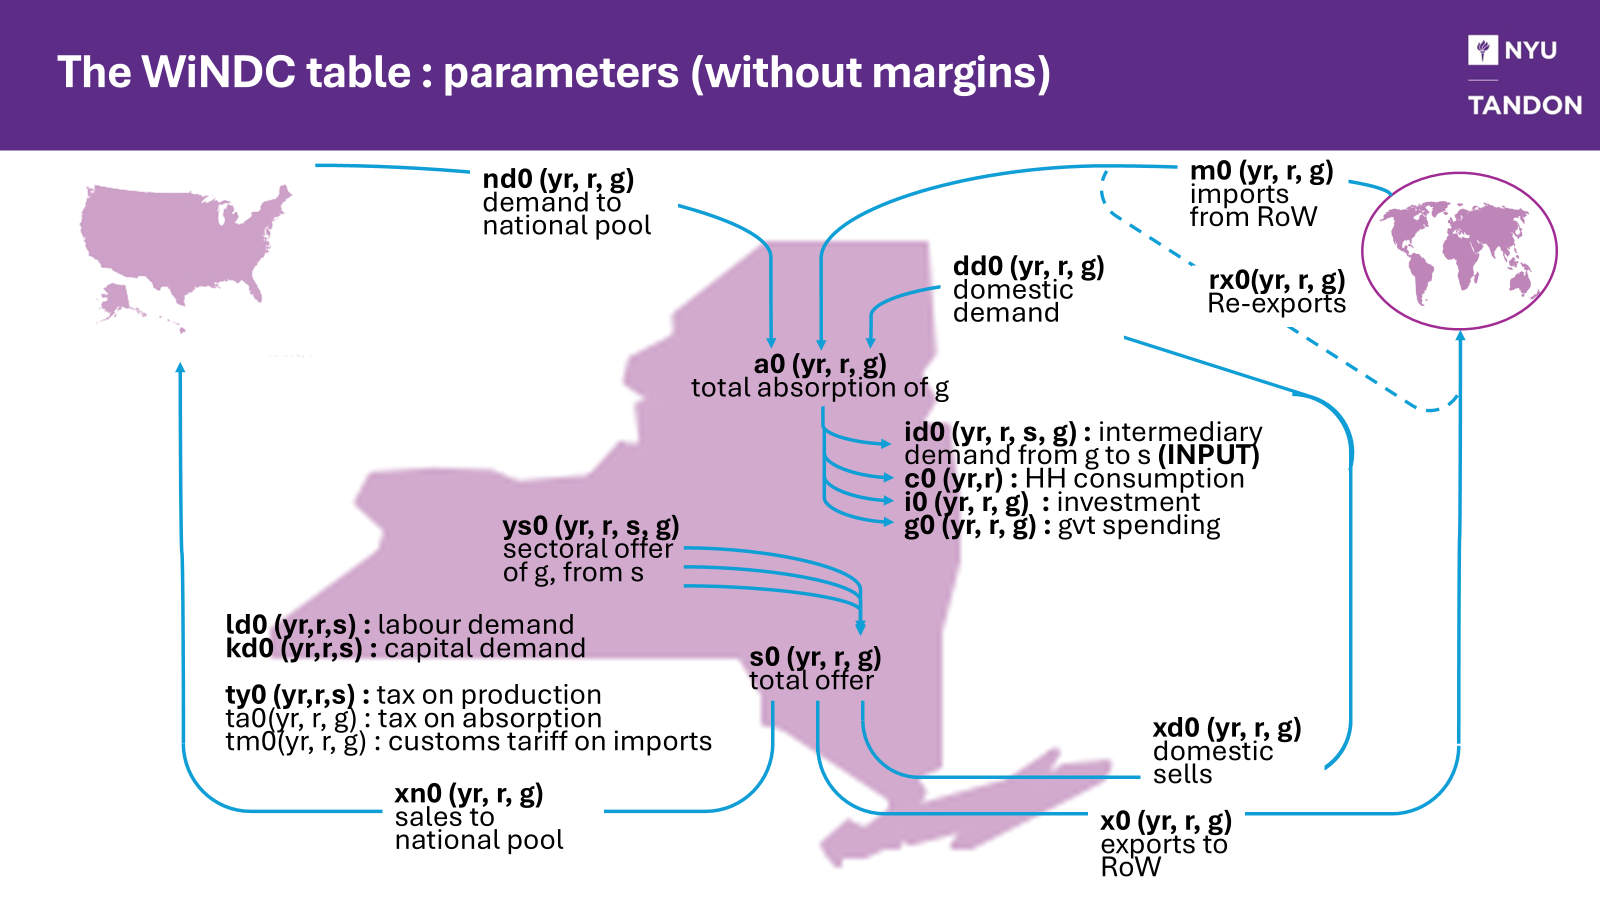

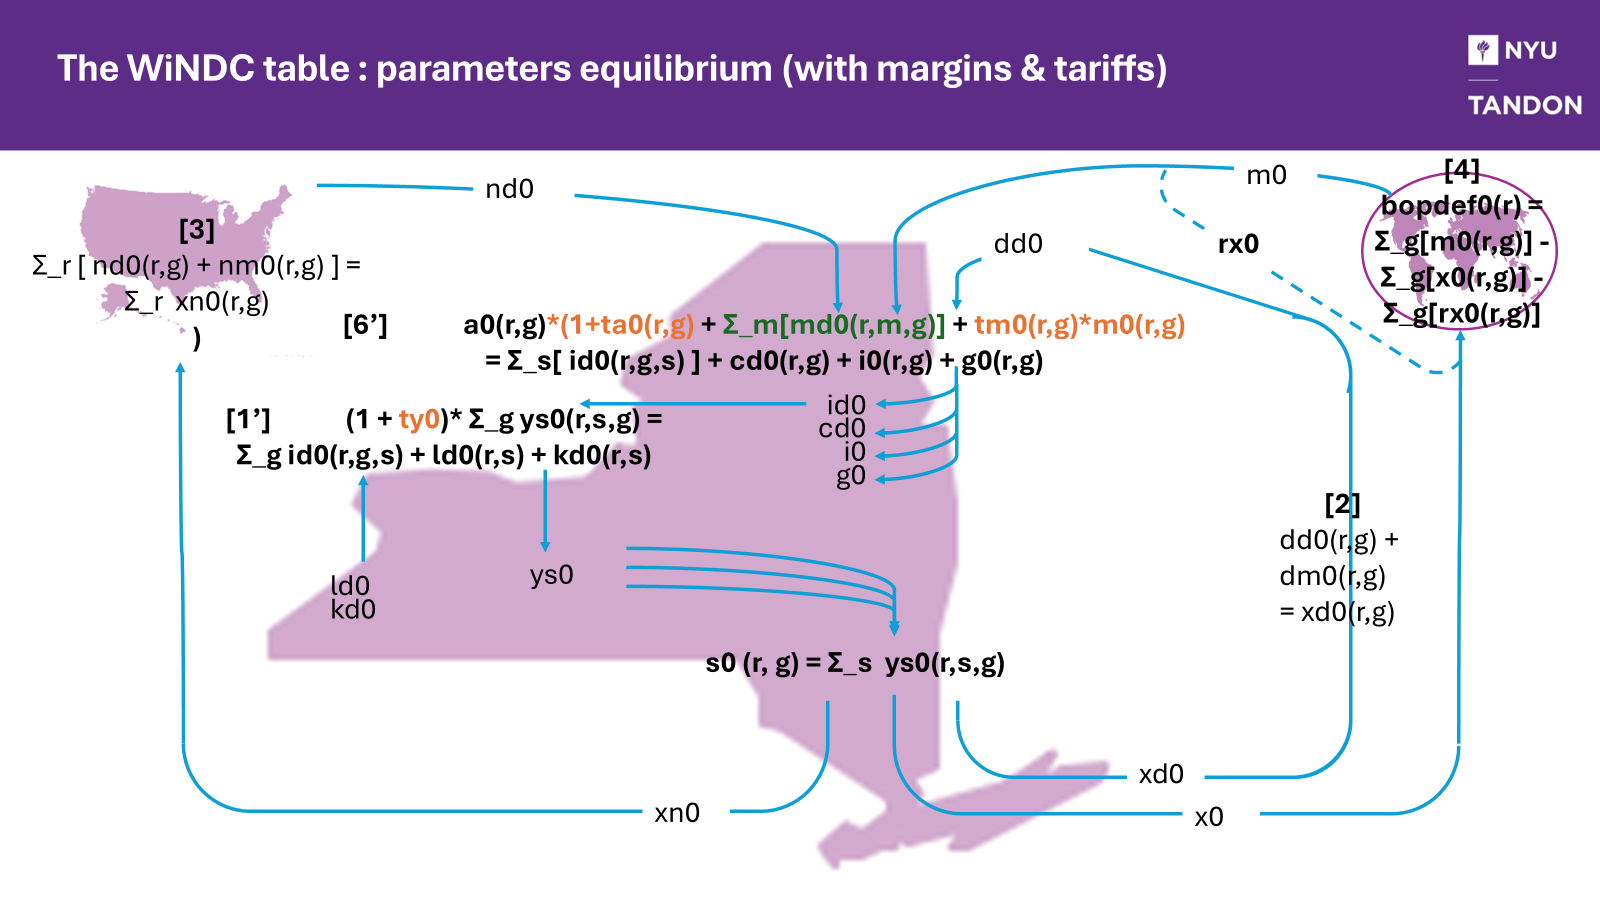

## Extraction

In [ ]:
path_windc_gdx = str(ROOT / "data/raw/GTAPWiNDC/data/core/WiNDCdatabase.gdx")

In [ ]:
gdx = GdxFile(path_windc_gdx, gams_dir=gamspybase_directory)
print(list(gdx))

In [ ]:
params = {name: obj for name, obj in gdx if isinstance(obj, GAMSParameter)}
print(list(params.keys()))

## Analysis

### Sets

In [ ]:
# Sets
sets = {name: list(obj) for name, obj in gdx if isinstance(obj, GAMSSet)}
print("=== SETS ===")
for name, values in sets.items():
    print(f"  {name}: {len(values)} elements — {values}")

##### **Why WiNDC has both `s` (sectors) and `g` (goods)?**

WiNDC inherits the BEA Input-Output framework, which distinguishes two fundamentally different economic units:

**`s` — industries (sectors)**: the unit of *production*. A sector is an economic activity
defined by who produces — a firm, a plant, or an industry group. It indexes the supply
side of the IO system: labor demand (`ld0_`), capital demand (`kd0_`), output taxes (`ty0_`).

**`g` — commodities (goods)**: the unit of *market flow*. A good is what circulates through
markets — what is bought, sold, imported, and exported. It indexes the demand side:
intermediate purchases (`id0_`), absorption (`a0_`), imports (`m0_`), trade flows (`xn0_`,
`nd0_`).

The two are linked by the **make table** `ys0_(yr, r, s, g)`, which records how much of
good `g` is produced by sector `s` in region `r`. 
- **A sector can produce multiple goods (secondary outputs)**
- **A good can be produced by multiple sectors**. 

For example, the
petroleum refining sector (`s='pet'`) primarily produces petroleum products (`g='pet'`)
but also yields chemical by-products (`g='che'`).

In WiNDC, both sets share the same 71 BEA Summary codes because the model uses an
**industry technology assumption**: each sector is primarily associated with one commodity
of the same code, making the make matrix `ys0_` **nearly** diagonal. This simplifies the CGE
structure while preserving the conceptual distinction required for a well-formed IO system.

##### **What is gm?**

`gm` is a subset of `g` (36 out of 71 goods) identifying commodities for which
transportation and trade margins are non-negligible in BEA accounts.

When a physical good moves from producer to buyer, its price increases by the cost
of intermediate transport and distribution services. WiNDC captures this through
`md0_(yr, r, m, g)` — the quantity of margin service `m` (transport `trn` or
trade `trd`) required to deliver good `g ∈ gm` to its user.

Goods outside `gm` — financial services, healthcare, education, real estate — are
intangible and delivered without a measurable physical margin.

The `gm` set contains three types of goods:
- **Physical tradeable goods** (agr, oil, che, fmt, pmt, ...): significant freight costs
- **Transport services themselves** (trk, air, wtt, pip, trn, otr, ott): they produce margins
- **Wholesale and retail trade** (wht, gmt, fbt): distribution margins

### Parameters

In [ ]:
# ── 1. Load all parameters ───────────────────────────────────────────────────
params = {}
for name, obj in gdx:
    if isinstance(obj, GAMSParameter):
        s = obj.to_pandas()
        if s is not None and len(s) > 0:
            df = s.reset_index()
            df.columns = list(df.columns[:-1]) + ['value']
            params[name] = df
# params contains all years and regions. We will filter it later when we need to build the IOT for a specific year and region.

##### **Params dictionnary structure**

params is a Python dictionary. Each key is the name of a GDX parameter (e.g. 'ys0_', 'id0_', 'xn0_'), and each value is a pandas DataFrame storing all non-zero records for that parameter in long (tidy) format.

Each row represents one non-zero cell of the tensor. The columns correspond to the parameter's index dimensions plus a final value column:

| Parameter | Dimensions | Meaning |
|-----------|------------|---------|
| `ys0_` | `yr, r, s, g` | Output of sector `s` as good `g` in region `r` |
| `id0_` | `yr, r, g, s` | Intermediate use of good `g` by sector `s` |
| `xn0_` | `yr, r, g` | Regional exports to the national pool |
| `nd0_` | `yr, r, g` | Regional imports from the national pool |
| `cd0_` | `yr, r, s` | Household consumption by sector |



Because storage is sparse (only non-zero entries), DataFrames have different lengths: a parameter that is non-zero for many region × sector × good combinations will have more rows than one that is mostly zero. This is why len(params['id0_']) >> len(params['xn0_']).

To extract a matrix for a given year, filter on yr, then groupby + unstack + reindex + fillna(0.0) — the last step is critical because unstack on sparse data introduces NaN for absent combinations.

#### Parameters analysis

In [ ]:
print(f"=== PARAMETERS ({len(params)}) ===")
for name, df in params.items():
    print(f"  {name}: {df.shape[0]:,} records, dims={df.columns.tolist()}")
#  records = number of non-zero entries corresponding to 1 combination of region, sector, and good for the parameter

##### **Some non-intuitive params**

- **`a0_(yr, r, g)`** — Armington aggregate: total absorption of good `g` in region `r`
at basic prices, combining all origins. By definition: `a0_ = dd0_ + nd0_ + m0_`.

- **`ta0_(yr, r, g)`** — Ad valorem tax rate on the Armington aggregate (a rate, not a dollar value). Captures consumption taxes and excise duties applied to total absorption.

- **`md0_(yr, m, r, g)`** — Total margin demand: value of trade/transport services
of type `m ∈ gm` required to deliver good `g` to region `r`. These margins bridge
basic prices and purchaser prices: `purchaser price = basic price + Σ_m md0_(m,r,g) + ta0_ · a0_`

  - **`dm0_(yr, m, r, g)`** — margin demand attributed to *locally*-sourced goods (`dd0_`)
  - **`nm0_(yr, m, r, g)`** — margin demand attributed to *nationally*-sourced goods (`nd0_`)

  so that `md0_ = dm0_ + nm0_` (plus margins on imports)


### Analysis of parameters

In [ ]:
# ── 2. Key IO parameters ─────────────────────────────────────────────────────
list_params = ['ys0_', 'id0_', 'm0_', 'x0_', 'rx0_', 'bopdef0_','hhadj0_','a0_',
       'dd0_', 'nd0_',
       'ld0_', 'kd0_', 
       'g0_', 'i0_', 
       'md0_', 
       'ty0_', 'tm0_','ta0_',
       'cd0_','c0_',
       'xd0_','xn0_']
io = {name: params[name] for name in list_params
      if name in params}
# the result is a dictionary of DataFrames, one per parameter, with columns corresponding to dimensions + 'value'

#### Example (NY,2017)

In [ ]:
# ── 4. New York 2017 ─────────────────────────────────────────────────────────
yr, region = '2017', 'NY'

In [ ]:
def filt(df, y, r):
    return df[(df['yr'] == y) & (df['r'] == r)]

id0_ny = filt(io['id0_'], yr, region)
ys0_ny = filt(io['ys0_'], yr, region)
m0_ny  = filt(io['m0_'],  yr, region)
x0_ny  = filt(io['x0_'],  yr, region)
i0_ny = filt(io['i0_'], yr, region)
rx0_ny = filt(io['rx0_'], yr, region)
md0_ny = filt(io['md0_'], yr, region)
ty0_ny = filt(io['ty0_'], yr, region)
tm0_ny = filt(io['tm0_'], yr, region)
dd0_ny = filt(io['dd0_'], yr, region)
nd0_ny = filt(io['nd0_'], yr, region)
ld0_ny = filt(io['ld0_'], yr, region)
kd0_ny = filt(io['kd0_'], yr, region)
g0_ny = filt(io['g0_'], yr, region)
ta0_ny = filt(io['ta0_'], yr, region)
cd0_ny = filt(io['cd0_'], yr, region)
c0_ny = filt(io['c0_'], yr, region)
bopdef0_ny = filt(io['bopdef0_'], yr, region)
hhadj0_ny = filt(io['hhadj0_'], yr, region)
a0_ny = filt(io['a0_'], yr, region)
xd0_ny = filt(io['xd0_'], yr, region)
xn0_ny = filt(io['xn0_'], yr, region)

print(f"\n=== NEW YORK {yr} ===")
print(f"  intermediary demand (INPUT) id0: {id0_ny.shape[0]} sector-good pairs, total = {id0_ny['value'].sum():.1f} $bn")
print(f"  sectoral production ys0: {ys0_ny.shape[0]} sector-good pairs, total = {ys0_ny['value'].sum():.1f} $bn")
print("")
print(f"  imports m0 : {m0_ny.shape[0]} sectors, total = {m0_ny['value'].sum():.1f} $bn")
#print(f"unique sectors in m0 = {m0_ny['g'].unique()}")
print(f"  exports x0 : {x0_ny.shape[0]} sectors, total = {x0_ny['value'].sum():.1f} $bn")
#print(f"unique sectors in x0 = {x0_ny['g'].unique()}")
print(f"  reexports rx0: {rx0_ny.shape[0]} sectors, total = {rx0_ny['value'].sum():.1f} $bn")
print(f"unique sectors in rx0 = {rx0_ny['g'].unique()}")
print(f"  balance of payments bopdef0: {bopdef0_ny.shape[0]} sectors, total = {bopdef0_ny['value'].sum():.1f} $bn")
print(f"  household adjustments hhadj0: {hhadj0_ny.shape[0]} aggregated adjustment, total = {hhadj0_ny['value'].sum():.1f} $bn")
print("")
print(f"  domestic demand dd0: {dd0_ny.shape[0]} sectors, total = {dd0_ny['value'].sum():.1f} $bn")
print(f"  domestic offer xd0: {xd0_ny.shape[0]} sectors, total = {xd0_ny['value'].sum():.1f} $bn")
print("")
print(f"  non-domestic  offer xn0: {xn0_ny.shape[0]} sectors, total = {xn0_ny['value'].sum():.1f} $bn")
print(f"  non-domestic demand nd0: {nd0_ny.shape[0]} sectors, total = {nd0_ny['value'].sum():.1f} $bn")
print(f"  absorption a0: {a0_ny.shape[0]} sector-good pairs, total = {a0_ny['value'].sum():.1f} $bn")
print("")
print(f"  consumption demand c0: {c0_ny.shape[0]} aggregated demand, total = {c0_ny['value'].sum():.1f} $bn")
print(f"  consumption demand cd0: {cd0_ny.shape[0]} sectors, total = {cd0_ny['value'].sum():.1f} $bn")
print(f"  government spending g0: {g0_ny.shape[0]} sectors, total = {g0_ny['value'].sum():.1f} $bn")
print(f"  investments i0 : {i0_ny.shape[0]} sectors, total = {i0_ny['value'].sum():.1f} $bn")

print("")
print(f"  margins demand md0: {md0_ny.shape[0]} sectors, total = {md0_ny['value'].sum():.1f} $bn")
print(f"  taxes on production ty0: {ty0_ny.shape[0]} sectors, total = {ty0_ny['value'].sum():.1f} $bn")
print(f"  taxes on imports tm0: {tm0_ny.shape[0]} sectors, total = {tm0_ny['value'].sum():.1f} $bn")
print(f"  taxes on absorption ta0: {ta0_ny.shape[0]} sectors, total = {ta0_ny['value'].sum():.1f} $bn")
print("")
print(f"  labor demand ld0: {ld0_ny.shape[0]} sectors, total = {ld0_ny['value'].sum():.1f} $bn")
print(f"  capital demand kd0: {kd0_ny.shape[0]} sectors, total = {kd0_ny['value'].sum():.1f} $bn")


#### SRIO (NY, 2017)

In [ ]:
use_matrix = id0_ny.pivot_table(
    index='g', columns='s', values='value', fill_value=0
)
print(f"\nUse matrix shape: {use_matrix.shape}")
print(use_matrix.iloc[:, :].round(2).to_string())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

data = use_matrix.copy()
vmin = data[data > 0].min().min()  # smallest positive value
vmax = data.max().max()

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    data,
    cmap="YlOrRd",
    norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
    linewidths=0,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Value (log scale)"},
    ax=ax,
)
ax.set_title("Use matrix (goods × sectors) — log scale, for NY in 2017", fontsize=14)
ax.set_xlabel("Sectors (s)")
ax.set_ylabel("Goods (g)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


#### Production of goods *g* by sectors *s*

In [ ]:
testparam = 'ys0_'
yr = '2017'
region = 'NY'

testmatrix_ny = filt(io[testparam], yr, region)

testmatrix = testmatrix_ny.pivot_table(index='g', columns='s', values='value', fill_value=0)

print(f"parameter : {testparam}")
print(f"Make table shape: {testmatrix.shape}")
print(testmatrix.iloc[:, :].round(2).to_string())

#### Exports & Imports to/from national pool

In [ ]:
# EXPORTS TO NATIONAL POOL
testparam = 'xn0_'
yr = '2017'
region = 'NY'

testmatrix_ny = filt(io[testparam], yr, region)

#testmatrix = testmatrix_ny.pivot_table(index='g', columns='s', values='value', fill_value=0)

print(f"parameter : {testparam}")
print(f"table shape: {testmatrix_ny.shape}")
print(testmatrix_ny.iloc[:, :].round(2).to_string())

In [ ]:
# IMPORTS FROM NATIONAL POOL
testparam = 'nd0_'
yr = '2017'
region = 'NY'

testmatrix_ny = filt(io[testparam], yr, region)

#testmatrix = testmatrix_ny.pivot_table(index='g', columns='s', values='value', fill_value=0)

print(f"parameter : {testparam}")
print(f"table shape: {testmatrix_ny.shape}")
print(testmatrix_ny.iloc[:, :].round(2).to_string())

#### Local Imports & Exports

In [ ]:
#LOCAL IMPORTS
testparam = 'dd0_'
yr = '2017'
region = 'NY'

testmatrix_ny = filt(io[testparam], yr, region)

#testmatrix = testmatrix_ny.pivot_table(index='g', columns='s', values='value', fill_value=0)

print(f"parameter : {testparam}")
print(f"table shape: {testmatrix_ny.shape}")
print(testmatrix_ny.iloc[:, :].round(2).to_string())

In [ ]:
# LOCAL EXPORTS
testparam = 'xd0_'
yr = '2017'
region = 'NY'

testmatrix_ny = filt(io[testparam], yr, region)

#testmatrix = testmatrix_ny.pivot_table(index='g', columns='s', values='value', fill_value=0)

print(f"parameter : {testparam}")
print(f"table shape: {testmatrix_ny.shape}")
print(testmatrix_ny.iloc[:, :].round(2).to_string())

#### Verification of margins equilibrium

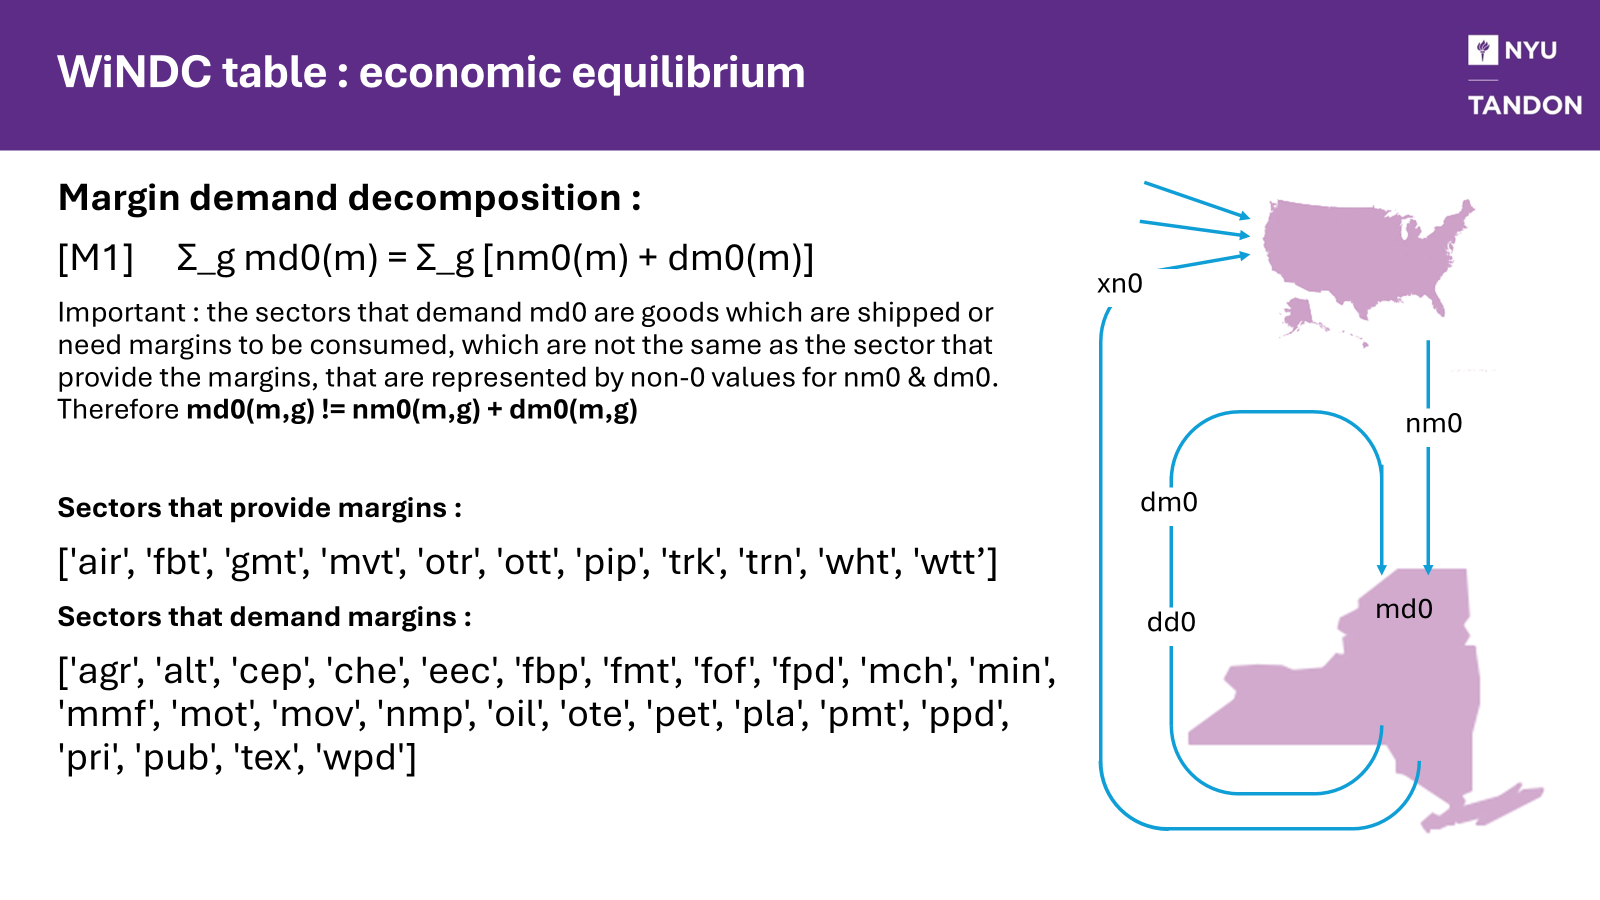

**Analysis of the verification of the equality md0 = nm0 + dm0 in the dataset**

In [ ]:
# ── Helper shared by every "official documentation" cross-check below ────────
# windc_construction.md states the identities the database is *built* to satisfy.
# Several of them differ from the formulas reverse-engineered above, so each one is
# re-tested here against the notebook's own version on exactly the same data.

def doc_rg(name, yr, dims=('r', 'g')):
    """Any param -> Series indexed by `dims`, summed over the other dimensions."""
    d = params[name][params[name]['yr'] == yr]
    ren = {}
    if 'g' in dims and 'g' not in d.columns and 's' in d.columns:
        ren = {'s': 'g'}                      # goods declared over the sector set
    d = d.rename(columns=ren)
    s = d.groupby(list(dims))['value'].sum()
    s.index = s.index.set_names(list(dims))
    return s


def doc_report(title, variants, scale=None, tol=1e-6):
    """variants: {label -> residual Series}. Prints one comparison table."""
    print("=" * 110)
    print(title)
    print("=" * 110)
    rows = []
    for label, r in variants.items():
        r = r.fillna(0.0)
        rows.append({
            'formulation': label,
            'sum resid': r.sum(),
            'sum |resid|': r.abs().sum(),
            'max |resid|': r.abs().max(),
            'n > 1e-6': int((r.abs() > tol).sum()),
            'n cells': len(r),
            '% of scale': (r.abs().sum() / scale.sum() * 100) if scale is not None else np.nan,
        })
    display(pd.DataFrame(rows).round(10))


In [ ]:
# -- Margin balance : md0 = nm0 + dm0 ----------------------------------------
# md0_(yr, r, m, g) : total demand for margin services
# nm0_(yr, r, g, m) : margin on the inter-state flows (national pool)
# dm0_(yr, r, g, m) : margin on the intra-state (domestic) flows

md0 = params['md0_'].rename(columns={'value': 'md0'})
nm0 = params['nm0_'].rename(columns={'value': 'nm0'})
dm0 = params['dm0_'].rename(columns={'value': 'dm0'})
dd0 = params['dd0_'].rename(columns={'value': 'dd0'})
nd0 = params['nd0_'].rename(columns={'value': 'nd0'})
a0 = params['a0_'].rename(columns={'value': 'a0'})
m0 = params['m0_'].rename(columns={'value': 'm0'})

merge_keys = ['yr', 'r', 'g', 'm']
margin_df = (
    md0.merge(nm0, on=merge_keys, how='outer')
       .merge(dm0, on=merge_keys, how='outer')
       .fillna(0.0)
)
other_merge_keys = ['yr', 'r', 'g']
margin_df = margin_df.merge(
    dd0, on=other_merge_keys, how='left'
).merge(
    nd0, on=other_merge_keys, how='left'
).merge(
    a0, on=other_merge_keys, how='left'
).merge(
    m0, on=other_merge_keys, how='left'
).fillna(0.0)

margin_df['residual']     = margin_df['md0'] - (margin_df['nm0'] + margin_df['dm0'])
margin_df['abs_residual'] = margin_df['residual'].abs()

tol      = 1
n_total  = len(margin_df)
n_violat = (margin_df['abs_residual'] > tol).sum()

print("=== Margin equilibrium: md0 = nm0 + dm0 ===")
print(f"Number of observations yr x r x m x g : {n_total:,}")
print(f"Violations (|residual| > {tol}) : {n_violat:,}  ({100*n_violat/n_total:.2f}%)")
print(f"Max residual  : {margin_df['abs_residual'].max():.6f}")
print(f"Mean residual : {margin_df['abs_residual'].mean():.8f}")

if n_violat > 0:
    print("\nTop 10 violations :")
    display(margin_df.nlargest(10, 'abs_residual')[
        ['yr', 'r', 'm', 'g', 'md0', 'nm0', 'dm0','nd0','dd0','m0', 'a0', 'residual']])
    print("\nTop 10 respect :")
    display(margin_df.nsmallest(10, 'abs_residual')[
        ['yr', 'r', 'm', 'g', 'md0', 'nm0', 'dm0','nd0','dd0','m0', 'a0', 'residual']])

else:
    print("Identity exactly satisfied for all observations.")

# Summary by (region, good) -- all years
by_rg = (
    margin_df.groupby(['r', 'g'])['abs_residual']
    .agg(['max', 'sum'])
    .rename(columns={'max': 'max_abs', 'sum': 'sum_abs'})
    .sort_values('sum_abs', ascending=False)
)
print("\n=== Top violations by (region, good) ===")
display(by_rg.head(15))


Conclusion: md0 is not equal to nm0 + dm0 in general. The sectors for which the equality is the least verified seem concentrated
_________________________________________________

**Analysis of the residuals by region and by sector**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# -- By sector (good g) ---------------------------------------------------------
by_yr_g = (
    margin_df.groupby(['yr', 'g'])['abs_residual']
    .sum()
    .reset_index()
)
sec_stats = (
    by_yr_g.groupby('g')['abs_residual']
    .agg(mean='mean', std='std')
    .fillna(0)
    .sort_values('mean', ascending=False)
)

ax = axes[0]
x = np.arange(len(sec_stats))
ax.bar(x, sec_stats['mean'], yerr=sec_stats['std'], capsize=3,
       color='steelblue', alpha=0.8, error_kw={'elinewidth': 1})
ax.set_xticks(x)
ax.set_xticklabels(sec_stats.index, rotation=90, fontsize=7)
ax.set_ylabel("Absolute residual (sum over r, m)")
ax.set_title("Distribution of residuals md0-(nm0+dm0) by sector  --  bar=mean over years, line=std")
ax.grid(axis='y', alpha=0.3)

# Annotate the global std
overall_std_g = sec_stats['std'].mean()
ax.text(0.99, 0.97, f'std moyen = {overall_std_g:.4f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# -- By region ----------------------------------------------------------------
by_yr_r = (
    margin_df.groupby(['yr', 'r'])['abs_residual']
    .sum()
    .reset_index()
)
reg_stats = (
    by_yr_r.groupby('r')['abs_residual']
    .agg(mean='mean', std='std')
    .fillna(0)
    .sort_values('mean', ascending=False)
)

ax = axes[1]
x = np.arange(len(reg_stats))
ax.bar(x, reg_stats['mean'], yerr=reg_stats['std'], capsize=3,
       color='darkorange', alpha=0.8, error_kw={'elinewidth': 1})
ax.set_xticks(x)
ax.set_xticklabels(reg_stats.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Absolute residual (sum over g, m)")
ax.set_title("Distribution of residuals md0-(nm0+dm0) by region  --  bar=mean over years, line=std")
ax.grid(axis='y', alpha=0.3)

overall_std_r = reg_stats['std'].mean()
ax.text(0.99, 0.97, f'std moyen = {overall_std_r:.4f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# Numerical summary
print(f"\nSector with highest mean residual : {sec_stats['mean'].idxmax()}  "
      f"(moy={sec_stats['mean'].max():.4f}, std={sec_stats.loc[sec_stats['mean'].idxmax(), 'std']:.4f})")
print(f"Region  with highest mean residual : {reg_stats['mean'].idxmax()}  "
      f"(moy={reg_stats['mean'].max():.4f}, std={reg_stats.loc[reg_stats['mean'].idxmax(), 'std']:.4f})")


Conclusion: the absolute residuals between md0 and nm0+dm0 are concentrated in certain sectors and regions now characterized.
___________________________________________________

**Cross-analysis of the md0 and nm0+dm0 values by region and by sector**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# -- Preparation --------------------------------------------------------------
margin_df['nm0_dm0'] = margin_df['nm0'] + margin_df['dm0']

# -- By region ----------------------------------------------------------------
by_yr_r = (
    margin_df.groupby(['yr', 'r'])[['md0', 'nm0_dm0']]
    .sum()
    .reset_index()
)
reg_md0  = by_yr_r.groupby('r')['md0'   ].agg(mean='mean', std='std').fillna(0)
reg_sum  = by_yr_r.groupby('r')['nm0_dm0'].agg(mean='mean', std='std').fillna(0)
order_r  = reg_md0['mean'].sort_values(ascending=False).index

ax = axes[0]
x  = np.arange(len(order_r))
w  = 0.4
ax.bar(x - w/2, reg_md0.loc[order_r, 'mean'], w,
       yerr=reg_md0.loc[order_r, 'std'], capsize=2,
       label='md0', color='steelblue', alpha=0.85)
ax.bar(x + w/2, reg_sum.loc[order_r, 'mean'], w,
       yerr=reg_sum.loc[order_r, 'std'], capsize=2,
       label='nm0 + dm0', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(order_r, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Value (sum over g, m)  --  yearly mean ± std")
ax.set_title("md0  vs  nm0+dm0  by region")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# -- By sector (good g) --------------------------------------------------------
by_yr_g = (
    margin_df.groupby(['yr', 'g'])[['md0', 'nm0_dm0']]
    .sum()
    .reset_index()
)
sec_md0 = by_yr_g.groupby('g')['md0'   ].agg(mean='mean', std='std').fillna(0)
sec_sum = by_yr_g.groupby('g')['nm0_dm0'].agg(mean='mean', std='std').fillna(0)
order_g = sec_md0['mean'].sort_values(ascending=False).index

ax = axes[1]
x  = np.arange(len(order_g))
ax.bar(x - w/2, sec_md0.loc[order_g, 'mean'], w,
       yerr=sec_md0.loc[order_g, 'std'], capsize=2,
       label='md0', color='steelblue', alpha=0.85)
ax.bar(x + w/2, sec_sum.loc[order_g, 'mean'], w,
       yerr=sec_sum.loc[order_g, 'std'], capsize=2,
       label='nm0 + dm0', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(order_g, rotation=90, fontsize=7)
ax.set_ylabel("Value (sum over r, m)  --  yearly mean ± std")
ax.set_title("md0  vs  nm0+dm0  by sector")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
colors = {'md0': 'steelblue', 'nm0': 'darkorange', 'dm0': 'seagreen'}
w = 0.28

# -- By region ----------------------------------------------------------------
by_yr_r = (
    margin_df.groupby(['yr', 'r'])[['md0', 'nm0', 'dm0']]
    .sum().reset_index()
)
stats_r = {
    col: by_yr_r.groupby('r')[col].agg(mean='mean', std='std').fillna(0)
    for col in ['md0', 'nm0', 'dm0']
}
order_r = stats_r['md0']['mean'].sort_values(ascending=False).index
x = np.arange(len(order_r))

ax = axes[0]
for i, col in enumerate(['md0', 'nm0', 'dm0']):
    ax.bar(x + (i-1)*w, stats_r[col].loc[order_r, 'mean'], w,
           yerr=stats_r[col].loc[order_r, 'std'], capsize=2,
           label=col, color=colors[col], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(order_r, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Value (sum over g, m)  --  yearly mean ± std")
ax.set_title("md0,  nm0,  dm0  by region")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# -- By sector ----------------------------------------------------------------
by_yr_g = (
    margin_df.groupby(['yr', 'g'])[['md0', 'nm0', 'dm0']]
    .sum().reset_index()
)
stats_g = {
    col: by_yr_g.groupby('g')[col].agg(mean='mean', std='std').fillna(0)
    for col in ['md0', 'nm0', 'dm0']
}
order_g = stats_g['md0']['mean'].sort_values(ascending=False).index
x = np.arange(len(order_g))

ax = axes[1]
for i, col in enumerate(['md0', 'nm0', 'dm0']):
    ax.bar(x + (i-1)*w, stats_g[col].loc[order_g, 'mean'], w,
           yerr=stats_g[col].loc[order_g, 'std'], capsize=2,
           label=col, color=colors[col], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(order_g, rotation=90, fontsize=7)
ax.set_ylabel("Value (sum over r, m)  --  yearly mean ± std")
ax.set_title("md0,  nm0,  dm0  by sector")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Conclusion: there is a balance md0 = nm0+dm0 at the region level, but not per sector. Per sector, in all the regions, there is exclusivity between the non-nullity of md0 and nm0+dm0: either md0 is non-zero, or it is nm0+dm0. The equality md0(r,s)=nm0(r,s)+dm0(r,s) is therefore false. On the other hand, for all r

$$\Sigma_s(md0(r,s)) =\Sigma_s(nm0(r,s)+dm0(r,s))$$


This therefore shows that there are 2 types of sectors: those for which md0!=0 and those for which nm0,dm0 !=0. It is not the same sectors that supply md0 and nm0,dm0

In [ ]:
# Margin-service supply m : sum over supplier goods (md0)
supply_m = (
    params['md0_']
    .groupby(['yr', 'r', 'm'])['value'].sum()
    .rename('md0_total')
)

# Margin-service demand m : sum over delivered goods (nm0 + dm0)
demand_m = (
    params['nm0_'].groupby(['yr', 'r', 'm'])['value'].sum()
    .add(params['dm0_'].groupby(['yr', 'r', 'm'])['value'].sum(), fill_value=0)
    .rename('nm0_dm0_total')
)

balance = supply_m.to_frame().join(demand_m, how='outer').fillna(0)
balance['residual'] = balance['md0_total'] - balance['nm0_dm0_total']
balance['abs_residual'] = balance['residual'].abs()

tol = 1e-6
n_total  = len(balance)
n_violat = (balance['abs_residual'] > tol).sum()

print("=== Market equilibrium: Σ_g md0(m) = Σ_g [nm0(m) + dm0(m)] ===")
print(f"Observations (yr, r, m) : {n_total:,}")
print(f"Violations              : {n_violat:,}  ({100*n_violat/n_total:.2f}%)")
print(f"Max residual  : {balance['abs_residual'].max():.6f}")
print(f"Mean residual : {balance['abs_residual'].mean():.8f}")

if n_violat > 0:
    display(balance.nlargest(10, 'abs_residual'))
else:
    print("Identity exactly satisfied.")


This test confirms the equality established previously.

We confirm that this dichotomy between sectors supplying dm0,nm0 or supplying md0 is the same in all the regions:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mean and std by (region, sector) over the years
by_yr_rg = (
    margin_df.groupby(['yr', 'r', 'g'])[['md0', 'nm0', 'dm0']]
    .sum().reset_index()
)
stats = (
    by_yr_rg.groupby(['r', 'g'])[['md0', 'nm0', 'dm0']]
    .agg(['mean', 'std'])
    .fillna(0)
)
# MultiIndex columns → (col, stat)
stats.columns = ['_'.join(c) for c in stats.columns]
stats = stats.reset_index()

regions_sorted = sorted(stats['r'].unique())
order_g = (
    stats.groupby('g')['md0_mean'].sum()
    .sort_values(ascending=False).index.tolist()
)

colors = {'md0': 'steelblue', 'nm0': 'darkorange', 'dm0': 'seagreen'}
w = 0.28
x = np.arange(len(order_g))

ncols = 6
nrows = int(np.ceil(len(regions_sorted) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5, nrows * 3),
                         sharey=False)
axes_flat = axes.flatten()

for ax_i, region in enumerate(regions_sorted):
    ax  = axes_flat[ax_i]
    sub = stats[stats['r'] == region].set_index('g').reindex(order_g).fillna(0)

    for i, col in enumerate(['md0', 'nm0', 'dm0']):
        ax.bar(x + (i-1)*w, sub[f'{col}_mean'], w,
               yerr=sub[f'{col}_std'], capsize=1.5,
               label=col, color=colors[col], alpha=0.85,
               error_kw={'elinewidth': 0.8})

    ax.set_title(region, fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(order_g, rotation=90, fontsize=5)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.tick_params(axis='y', labelsize=6)

# Legend on the first axis, hide the empty axes
axes_flat[0].legend(fontsize=7, loc='upper right')
for ax in axes_flat[len(regions_sorted):]:
    ax.set_visible(False)

fig.suptitle("md0,  nm0,  dm0  by sector -- mean over years ± std\n(one plot per region)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


The structure is indeed similar from one region to another and therefore depends only on the nature of the sectors. The exclusivity property of md0 and nm0,dm0 is therefore directly linked to the definition and the nature of the sectors

Conclusion : 
- md0 describes the demand of margins from final consumption goods
- nm0 & dm0 describe the margins provided by margin-providing sectors (trasnportation, etc)

In [ ]:
g_md0 = set(params['md0_']['g'].unique())   # margin suppliers
g_nm0 = set(params['nm0_']['g'].unique())   # demanders (delivered goods)
g_dm0 = set(params['dm0_']['g'].unique())

print("=== Sectors g in md0_ (goods that require margins) ===")
print(sorted(g_md0))

print("\n=== Sectors g in nm0_/dm0_ (margin-service suppliers) ===")
print(sorted(g_nm0 | g_dm0))

#### Cross-check against the official documentation — margins

`methodologies/windc_construction.md` does not leave the margin structure to be discovered:

* **eq. (28)** builds state margin supply as a proportional share-out of a **national**
  total, `ms^(r,g,m) = [Σ_g' md(r,m,g') / Σ_{r',g'} md] · ms~(g,m)`. If `ms~(g,m) = 0` the
  good supplies no margin **in any state** — the dichotomy found above is a construction
  artefact, not an empirical regularity, and its invariance across the 51 states is
  mechanical.
* **eq. (36)** states `Σ_g md0(r,m,g) = Σ_g [nm0+dm0](r,g,m)` for every (r,m) as an
  accounting identity *in the data* — i.e. exactly what cell 61 rediscovered.
* **eq. (31)** states `xd0(r,g) = dd0(r,g) + Σ_m dm0(r,g,m)`, exact **per (r,g)** — a much
  stronger statement than the "≈, summed over r" version used above.
* the `gm` set of the doc (l. 7074) is the **union** of the two families, not a partition,
  so the partition still has to be established from the data.

The cell below re-tests all three and quantifies the margin intensity.

In [ ]:
year = '2017'

# eq. (36) — margin market clearing, per (r, m)
M = pd.concat({k: doc_rg(f'{k}0_', year, ('r', 'm')) for k in ['md', 'nm', 'dm']},
              axis=1).fillna(0.0)
# eq. (31) — local supply, per (r, g)  vs  the weaker "summed over r" version
L = pd.concat({'xd0': doc_rg('xd0_', year), 'dd0': doc_rg('dd0_', year),
               'dm0': doc_rg('dm0_', year)}, axis=1).fillna(0.0)

doc_report(f'DOC eq.(36) and eq.(31) — margins  [{year}]', {
    'DOC eq.(36): Σ_g md0(r,m,g) = Σ_g [nm0+dm0](r,g,m)   per (r,m)':
        M['md'] - (M['nm'] + M['dm']),
    'DOC eq.(31): xd0 = dd0 + Σ_m dm0                     per (r,g)':
        L['xd0'] - (L['dd0'] + L['dm0']),
    'weaker version used above: same, summed over r        per g':
        L['xd0'].groupby('g').sum() - (L['dd0'] + L['dm0']).groupby('g').sum(),
}, scale=L['xd0'])

# ── margin intensity: how many goods are near-pure margin providers? ─────────
rows = []
for y in sorted(params['ys0_']['yr'].unique()):
    ms = doc_rg('nm0_', y, ('g',)).add(doc_rg('dm0_', y, ('g',)), fill_value=0)
    out = doc_rg('ys0_', y, ('g',))
    inten = (ms / out.replace(0, np.nan)).fillna(0)
    rows.append({'yr': y, '>=90%': int((inten >= 0.90).sum()),
                 '>=75%': int((inten >= 0.75).sum()), '>=50%': int((inten >= 0.50).sum()),
                 'any margin supply': int((ms > 0).sum())})
print('\nGoods whose margin supply (nm0+dm0) exceeds a share of their output Σ_s ys0:')
display(pd.DataFrame(rows))

ms = doc_rg('nm0_', year, ('g',)).add(doc_rg('dm0_', year, ('g',)), fill_value=0)
out = doc_rg('ys0_', year, ('g',))
MI = pd.concat([ms.rename('margin_supply'), out.rename('output')], axis=1).fillna(0.0)
MI['intensity'] = MI['margin_supply'] / MI['output'].replace(0, np.nan)
print(f'\n=== margin intensity, {year} (top 12) ===')
display(MI.sort_values('intensity', ascending=False).head(12).round(4))

sup = set(MI[MI['margin_supply'] > 0].index)
dem = set(doc_rg('md0_', year, ('g',)).index)
print(f'goods supplying margins : {len(sup)} -> {sorted(sup)}')
print(f'goods demanding margins : {len(dem)}')
print(f'intersection            : {sorted(sup & dem)}   <- empty = strict dichotomy')
print(f'union (= doc set `gm`)  : {len(sup | dem)} goods')

# the dichotomy state by state (doc eq. 28 predicts a single common support)
sup_rg = doc_rg('nm0_', year).add(doc_rg('dm0_', year), fill_value=0)
dem_rg = doc_rg('md0_', year)
sup_sets = {r: frozenset(s[s > 0].index.get_level_values('g')) for r, s in sup_rg.groupby(level='r')}
dem_sets = {r: frozenset(s[s > 0].index.get_level_values('g')) for r, s in dem_rg.groupby(level='r')}
print(f'distinct margin-supply supports across the 51 states : {len(set(sup_sets.values()))}')
print(f'distinct margin-demand supports across the 51 states : {len(set(dem_sets.values()))}')

**Result.** Both documented identities hold to storage precision (eq. 36: 9e-10 ; eq. 31:
2.5e-06 with **zero** cells above 1e-6). eq. (31) is exact **cell by cell**, so the
"≈ summed over r" formulation used earlier is needlessly weak and should be replaced by it.

Margin intensity is stable over the whole 1997-2023 span: **exactly 8 goods** have a margin
supply of at least 75% of their output — `fbt, gmt, mvt, ott, pip, trk, trn, wht` — and the
same 8 at the 50% threshold, so the count is not threshold-sensitive. `wtt` sits at 40% and
must **not** be counted among them. 11 goods supply some margin, 25 demand some, the
intersection is **empty**, and the union is exactly the 36-good `gm` set of the doc — which
confirms that `gm` is the union of the two families and not the partition itself. Both
supports are identical across the 51 states (1 distinct support each), as eq. (28) predicts.

#### Verification of market clearance

Also named Armington identity

The following code tests whether a0 is defined to be equal to 
- a0 = dd0 + nd0 + m0
- a0 = dd0 + nd0 + m0 - rx0
- a0 = dd0 + nd0 + m0(1+tm0) - rx0
- a0 = dd0 + nd0 + m0(1+tm0) - rx0 + margins

In [ ]:
year = '2017'  # or loop over all years

def load_param(name, yr):
    df = params[name][params[name]['yr'] == yr].copy()
    return df.groupby(['r', 'g'])['value'].sum()

a0  = load_param('a0_',  year).rename('a0')
dd0 = load_param('dd0_', year).rename('dd0')
nd0 = load_param('nd0_', year).rename('nd0')
m0  = load_param('m0_',  year).rename('m0')
rx0 = load_param('rx0_', year).rename('rx0')
ta0 = load_param('ta0_', year).rename('ta0')

# tm0 is a rate -> compute tm0 * m0
tm0_rate = params['tm0_'][params['tm0_']['yr'] == year].groupby(['r','g'])['value'].sum().rename('tm0')
tariff   = (m0 * tm0_rate).rename('tariff').fillna(0)

# margins = Σ_m md0(r, m, g) per (r, g)
md0 = (
    params['md0_'][params['md0_']['yr'] == year]
    .groupby(['r', 'g'])['value'].sum()
    .rename('md0')
)
nm0 = (
    params['nm0_'][params['nm0_']['yr'] == year]
    .groupby(['r', 'g'])['value'].sum()
    .rename('nm0')
)
dm0 = (
    params['dm0_'][params['dm0_']['yr'] == year]
    .groupby(['r', 'g'])['value'].sum()
    .rename('dm0')
)


df = pd.concat([a0, dd0, nd0, m0, rx0, tariff, md0, nm0, dm0], axis=1).fillna(0)

formulas = {
    'f1: a0 - (dd0+nd0+m0)':                df['dd0'] + df['nd0'] + df['m0'],
    'f2: a0 - (dd0+nd0+m0-rx0)':            df['dd0'] + df['nd0'] + df['m0'] - df['rx0'],
    'f3: a0 - (dd0+nd0+m0(1+tm0)-rx0)':     df['dd0'] + df['nd0'] + df['m0'] + df['tariff'] - df['rx0'],
    'f4: a0 - (dd0+nd0+m0(1+tm0)-rx0+md0)':df['dd0'] + df['nd0'] + df['m0'] + df['tariff'] - df['rx0'] + df['md0'],
    'f5: a0 - (dd0+nd0+m0(1+tm0)-rx0+md0+nm0+dm0)': df['dd0'] + df['nd0'] + df['m0'] + df['tariff'] - df['rx0']+ df['md0'] +  df['nm0'] + df['dm0'],
}

print(f"{'Formula':<35} | {'max|resid| on (r, g)':>12} | {'mean|resid| on (r,g)':>12} | {'sum resid on (r, g)':>12} | {'abs sum resid on (r,g)':>12} | {'RMSE':>10}")
print("-" * 90)
for label, rhs in formulas.items():
    resid     = df['a0'] - rhs
    abs_resid = resid.abs()
    safe_a0   = df['a0'].where(df['a0'].abs() > 1e-10, np.nan)
    print(f"{label:<35} | {abs_resid.max():>12.4f} | {abs_resid.mean():>12.6f} | "
          f"{resid.sum():>12.4f} | {abs_resid.sum():>12.4f} | {np.sqrt((resid**2).mean()):>10.6f}")

# Worst sectors for the best formula (lowest max residual)
best_label, best_rhs = min(formulas.items(),
                           key=lambda kv: (df['a0'] - kv[1]).abs().max())
resid_best = (df['a0'] - best_rhs).abs().rename('abs_resid')
worst = resid_best.nlargest(15).reset_index()
print(f"\nTop 15 worst (r, g) pairs for best formula [{best_label}]:")
display(worst)



The complete formula is (dd0+nd0+m0(1+tm0)-rx0+md0). However the maximum error stays large (13bn$). Here again, the residuals between a0 and its assumed formula from the other variables (dd0+nd0+m0(1+tm0)-rx0+md0) seem to be concentrated in certain sectors and certain regions:

In [ ]:
all_years = sorted(params['a0_']['yr'].unique())

def load_rg(name, yr, value_col='value'):
    df = params[name][params[name]['yr'] == yr]
    return df.groupby(['r','g'])[value_col].sum()

records = []
for yr in all_years:
    # Build a single DataFrame with all variables, aligned on (r,g)
    pieces = {
        'a0' : load_rg('a0_',  yr),
        'dd0': load_rg('dd0_', yr),
        'nd0': load_rg('nd0_', yr),
        'm0' : load_rg('m0_',  yr),
        'rx0': load_rg('rx0_', yr),
        'tm0': load_rg('tm0_', yr),
        'md0': (params['md0_'][params['md0_']['yr'] == yr]
                .groupby(['r','g'])['value'].sum()),
    }
    base = pd.concat(pieces, axis=1).fillna(0)

    if base.empty:
        print(f"WARNING: empty for yr={yr!r}")
        continue

    base['rhs']   = (base['dd0'] + base['nd0']
                     + base['m0'] * (1 + base['tm0'])
                     - base['rx0'] + base['md0'])
    base['resid'] = base['a0'] - base['rhs']
    base['yr']    = yr
    records.append(base[['yr','resid']].reset_index())

if not records:
    print("No data — check year type or param names")
else:
    df_all = pd.concat(records, ignore_index=True)
    print(f"Total obs: {len(df_all)}, NaN residuals: {df_all['resid'].isna().sum()}")

    good_stats = (df_all.groupby('g')['resid']
                  .agg(mean='mean', std='std').fillna(0)
                  .sort_values('mean', key=abs, ascending=False))
    reg_stats  = (df_all.groupby('r')['resid']
                  .agg(mean='mean', std='std').fillna(0)
                  .sort_values('mean', key=abs, ascending=False))

    fig, axes = plt.subplots(2, 1, figsize=(16, 11))
    for ax, stats, title, color in [
        (axes[0], good_stats, 'Residual by good   (mean ± std  —  all years & regions)', 'steelblue'),
        (axes[1], reg_stats,  'Residual by region (mean ± std  —  all years & goods)',   'darkorange'),
    ]:
        x = np.arange(len(stats))
        ax.bar(x, stats['mean'], color=color, alpha=0.8,
               yerr=stats['std'], capsize=3, error_kw={'elinewidth': 0.8})
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels(stats.index,
                           rotation=90 if ax is axes[0] else 45,
                           ha='center'  if ax is axes[0] else 'right',
                           fontsize=8)
        ax.set_ylabel('Residual (mean)')
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
        ax.text(0.99, 0.97, f'global std = {stats["std"].mean():.4f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.show()

    print("=== Top 10 goods by |mean residual| ===")
    display(good_stats.head(10))
    print("\n=== Top 10 regions by |mean residual| ===")
    display(reg_stats.head(10))


We test the integration of the tax ta0 into this formula:

In [ ]:
import itertools

year = '2017'

# ── Aligned (r, g) table — ta0/tm0 are RATES, tariff = tm0 * m0 ──────────────
a0  = load_param('a0_',  year).rename('a0')
dd0 = load_param('dd0_', year).rename('dd0')
nd0 = load_param('nd0_', year).rename('nd0')
m0  = load_param('m0_',  year).rename('m0')
rx0 = load_param('rx0_', year).rename('rx0')
ta0 = load_param('ta0_', year).rename('ta0')          # absorption tax rate

tm0_rate = (params['tm0_'][params['tm0_']['yr'] == year]
            .groupby(['r', 'g'])['value'].sum().rename('tm0'))
tariff = (m0 * tm0_rate).rename('tariff')

md0 = (params['md0_'][params['md0_']['yr'] == year]
       .groupby(['r', 'g'])['value'].sum().rename('md0'))

df = pd.concat([a0, dd0, nd0, m0, rx0, ta0, tm0_rate, tariff, md0], axis=1).fillna(0)

# ── Additive RHS terms (signed); the block is indissociable ──────────────────
terms = {
    'block(dd0+nd0+m0)': df['dd0'] + df['nd0'] + df['m0'],
    'tariff(tm0*m0)'    : df['tariff'],
    '-rx0'              : -df['rx0'],
    'md0'               : df['md0'],
}
factor = 1 + df['ta0']          # (1 + ta0) multiplier
names  = list(terms)

# ── Test every placement of (1+ta0): LHS (a0) + each of the 4 RHS terms ──────
results = []
for flags in itertools.product([0, 1], repeat=1 + len(names)):
    lhs_flag, *rhs_flags = flags

    lhs = df['a0'] * (factor if lhs_flag else 1.0)
    rhs = sum(term * (factor if fl else 1.0)
              for term, fl in zip(terms.values(), rhs_flags))
    resid = lhs - rhs

    lhs_lbl = 'a0*(1+ta0)' if lhs_flag else 'a0'
    rhs_lbl = ' + '.join(f"{n}{'*(1+ta0)' if fl else ''}"
                         for n, fl in zip(names, rhs_flags))
    results.append({
        'LHS': lhs_lbl, 'RHS': rhs_lbl,
        'max|resid|' : resid.abs().max(),
        'mean|resid|': resid.abs().mean(),
        'sum resid'  : resid.sum(),
        'abs sum resid': resid.abs().sum(),
        'RMSE'       : np.sqrt((resid ** 2).mean()),
    })

# ── Extra hand-built candidates (structure outside the on/off grid) ──────────
special = {
    'a0 = (dd0+nd0+(m0-rx0)(1+tm0)+md0)(1+ta0)':
        (df['dd0'] + df['nd0'] + (df['m0'] - df['rx0']) * (1 + df['tm0']) + df['md0'])
        * (1 + df['ta0']),
}
for label, rhs in special.items():
    resid = df['a0'] - rhs
    results.append({
        'LHS': 'a0', 'RHS': label,
        'max|resid|' : resid.abs().max(),
        'mean|resid|': resid.abs().mean(),
        'sum resid'  : resid.sum(),
        'abs sum resid': resid.abs().sum(),
        'RMSE'       : np.sqrt((resid ** 2).mean()),
    })

res_df = (pd.DataFrame(results)
          .sort_values('max|resid|')
          .reset_index(drop=True))

pd.set_option('display.max_colwidth', None)
print(f"=== ta0 placement test ({year}) — {len(res_df)} combinations, best first ===")
display(res_df.head(15))


Conclusion:

The formulas
- block(dd0+nd0+m0)*(1+ta0) + tariff(tm0*m0)*(1+ta0) + -rx0 + md0*(1+ta0)
- block(dd0+nd0+m0)*(1+ta0) + tariff(tm0*m0)*(1+ta0) + -rx0*(1+ta0) + md0*(1+ta0)
- (dd0+nd0+(m0-rx0)(1+tm0)+md0)(1+ta0)
- block(dd0+nd0+m0)*(1+ta0) + tariff(tm0*m0) + -rx0*(1+ta0) + md0*(1+ta0)
- block(dd0+nd0+m0)*(1+ta0) + tariff(tm0*m0) + -rx0 + md0*(1+ta0)

constitute a huge improvement over block(dd0+nd0+m0) + tariff(tm0.m0) + -rx0 + md0 which gave the closest result according to the previous cell. There is therefore a hesitation as to whether the tax ta0 should be applied to tariff(tm0*m0) + -rx0 or not.

In [ ]:
eps   = 1e-10
block = df['dd0'] + df['nd0'] + df['m0']

# ════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 1 — Are nonzero ta0, tariff (tm0*m0) and rx0 mutually exclusive?
# ════════════════════════════════════════════════════════════════════════════
nz = pd.DataFrame({
    'ta0'   : df['ta0'].abs()    > eps,
    'tariff': df['tariff'].abs() > eps,
    'rx0'   : df['rx0'].abs()    > eps,
})
n_cells = len(nz)

print(f"=== HYPOTHESIS 1: mutual exclusivity ({n_cells} (r,g) cells) ===\n")
print("Non-zero cells per term:")
print(nz.sum().to_string())

print("\nPairwise / triple co-occurrence of non-zero values (# cells):")
print(f"  ta0 & tariff        : {(nz['ta0'] & nz['tariff']).sum()}")
print(f"  ta0 & rx0           : {(nz['ta0'] & nz['rx0']).sum()}")
print(f"  tariff & rx0        : {(nz['tariff'] & nz['rx0']).sum()}")
print(f"  ta0 & tariff & rx0  : {(nz['ta0'] & nz['tariff'] & nz['rx0']).sum()}")

# Exact reason a flag does (or does not) matter:
# attaching (1+ta0) to term X shifts the RHS by exactly  Σ ta0*X
print("\nExact effect of attaching (1+ta0) to each term  [= Σ ta0*X]:")
total_a0 = df['a0'].sum()
for name in ['tariff', 'rx0', 'md0', 'block']:
    col   = block if name == 'block' else df[name]
    addon = df['ta0'] * col
    print(f"  Σ ta0*{name:<7} = {addon.sum():13.6f}  "
          f"({addon.sum()/total_a0*100:7.4f}% of Σa0)  "
          f"nonzero on {(addon.abs() > eps).sum():>4} cells")

# ════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 2 — Relative magnitude of each block
# ════════════════════════════════════════════════════════════════════════════
print(f"\n=== HYPOTHESIS 2: relative magnitude ===\n")
sizes = pd.DataFrame({
    'block(dd0+nd0+m0)': block,
    'tariff(tm0*m0)'   : df['tariff'],
    'rx0'              : df['rx0'],
    'md0'              : df['md0'],
})
summary = pd.DataFrame({
    'sum'                : sizes.sum(),
    'mean_all'           : sizes.mean(),
    'mean_nonzero'       : sizes.where(sizes.abs() > eps).mean(),
    'n_nonzero'          : (sizes.abs() > eps).sum(),
    '% of block sum'     : sizes.sum() / block.sum() * 100,
})
display(summary.round(4))


Conclusion: these tests do not allow deciding on the inclusion or not of these terms in the formula. We must therefore proceed logically.
ta0 is an ad valorem tax on the Armington aggregate consumed on site.
The re-exports rx0 are subtracted from m0 because not consumed domestically. The tax ta0 must therefore be applied to this subtraction.
The tariff tm0·m0 is part of the base price paid by the domestic buyer → logically in the base (tariff*(1+ta0)).

The formula is therefore assumed to be, for all (r,g):

$$ a0 = ( dd0 + nd0 + (m0- rx0)*( 1 + tm0 ) + md0 )*( 1 + ta0 ) 

#### Cross-check against the official documentation — Armington, producer side

The sweep above assumed the source leaves the formula under-determined. It does not.
`windc_construction.md` **defines** `nd0` by this very equation:

> **eq. (27)** `nd̄ = (1-ta̅)ā + rx̄ - dd̄ - (1+tm̄)m̄ - Σ_m md̄`
> restated as the zero-profit condition **eq. (35)** and, at the national level, **eq. (5)**.

It differs from the formula retained above on two points:

| | documentation | notebook |
|---|---|---|
| tax factor | `(1-ta0)·a0` on the left, i.e. `a0 = base/(1-ta0)` | `a0 = base·(1+ta0)` |
| `rx0` | outside the tariff factor, added to the left | inside: `(1+tm0)(m0-rx0)` |

`1/(1-ta0)` and `(1+ta0)` agree only to first order in `ta0`, so the two formulas differ by
`≈ ta0²·base` — which is largest exactly where `ta0` is largest. The cell below tests the
documented formula, the two notebook variants, and the two hybrids that isolate each
difference.

In [ ]:
year = '2017'

def arm_table(yr):
    cols = ['a0_', 'dd0_', 'nd0_', 'm0_', 'rx0_', 'ta0_', 'tm0_', 'md0_']
    return pd.concat({c.rstrip('_'): doc_rg(c, yr) for c in cols}, axis=1).fillna(0.0)


def arm_variants(X):
    basic   = X['dd0'] + X['nd0'] + X['md0']
    imp_doc = (1 + X['tm0']) * X['m0']                  # doc : rx0 outside the tariff factor
    imp_nb  = (1 + X['tm0']) * (X['m0'] - X['rx0'])     # nb  : rx0 inside
    return {
        'DOC eq.(35) : (1-ta0)a0 + rx0 = dd0+nd0+(1+tm0)m0+md0':
            (1 - X['ta0']) * X['a0'] + X['rx0'] - (basic + imp_doc),
        'NB (cell 80): a0 = [dd0+nd0+(1+tm0)(m0-rx0)+md0](1+ta0)':
            X['a0'] - (basic + imp_nb) * (1 + X['ta0']),
        'NB (cell 86): a0 = [dd0+nd0+(1+tm0)m0+md0](1+ta0) - rx0':
            X['a0'] - ((basic + imp_doc) * (1 + X['ta0']) - X['rx0']),
        'HYB tax=doc, rx0=nb : (1-ta0)a0 = dd0+nd0+(1+tm0)(m0-rx0)+md0':
            (1 - X['ta0']) * X['a0'] - (basic + imp_nb),
        'HYB tax=nb , rx0=doc: a0 = [dd0+nd0+(1+tm0)m0+md0-rx0](1+ta0)':
            X['a0'] - (basic + imp_doc - X['rx0']) * (1 + X['ta0']),
    }


X = arm_table(year)
doc_report(f'DOC eq.(27)/(35) vs the notebook formula  [{year}, (r,g) cells]',
           arm_variants(X), scale=X['a0'])

# the same test on every year of the database
rows = []
for y in sorted(params['a0_']['yr'].unique()):
    Xy = arm_table(y)
    v  = list(arm_variants(Xy).values())
    rows.append({'yr': y, 'Σa0': Xy['a0'].sum(),
                 'doc Σ|res|': v[0].abs().sum(), 'doc %': v[0].abs().sum() / Xy['a0'].sum() * 100,
                 'nb  Σ|res|': v[1].abs().sum(), 'nb  %': v[1].abs().sum() / Xy['a0'].sum() * 100})
print('\nResidual of both formulas, every year:')
display(pd.DataFrame(rows).round(6))

# where the notebook residual sits, and how it correlates with the tax rate
v = arm_variants(X)
r_doc, r_nb = list(v.values())[0], list(v.values())[1]
by_g = pd.DataFrame({
    'doc |res|': r_doc.abs().groupby('g').sum(),
    'nb  |res|': r_nb.abs().groupby('g').sum(),
    'a0'       : X['a0'].groupby('g').sum(),
    'mean ta0' : X['ta0'].groupby('g').mean(),
})
by_g['nb % of a0'] = by_g['nb  |res|'] / by_g['a0'] * 100
print(f'\n=== 10 goods carrying the notebook residual ({year}) ===')
display(by_g.sort_values('nb  |res|', ascending=False).head(10).round(6))
corr = r_nb.abs().corr(X['ta0'] ** 2 * X['a0'])
print(f'\nthe notebook residual tracks the second-order tax term ta0^2 * a0:')
print(f'  corr( |resid_nb| , ta0^2 * a0 ) = {corr:.4f}')

**Result — the earlier conclusion is wrong and must be replaced.**

| formulation | Σ&#124;residual&#124; (2017) | cells > 1e-6 | over 1997-2023 |
|---|---|---|---|
| **DOC eq. (35)** | **3.2e-06 $bn** (9e-09 % of `a0`) | **0 / 3468** | **0.0000 every year** |
| NB cell 80 | 39.54 $bn (0.114 %) | 2900 / 3468 | 25-53 $bn every year |
| NB cell 86 | 39.77 $bn (0.114 %) | 2900 / 3468 | — |
| HYB tax=doc, rx0=nb | 0.345 $bn | 50 / 3468 | — |
| HYB tax=nb, rx0=doc | 39.19 $bn | 2900 / 3468 | — |

The documented formula is **exact on every cell of every year**. The two hybrids attribute
39.19 of the 39.54 $bn to the **tax convention** (`(1+ta0)` instead of `1/(1-ta0)`) and the
remaining 0.35 $bn to the **`rx0` placement**.

Consequently:
* the "residual concentrated in `pet`, `fbp`, `res`, `air`" is not a defect of the data — those
  are simply the goods with the highest `ta0` (excise on fuel, sales tax on food and
  restaurants, ticket tax on air travel), where the second-order term `ta0²·base` is largest;
* the 3.5 ‰ overall residual disappears entirely;
* the "identification" discussion (the supports of `ta0`, `tm0·m0` and `rx0` barely overlap,
  so the placement cannot be decided) is moot: the source *defines* `nd0` by eq. (27), and
  that definition reproduces `a0` to machine precision.

**Retained identity:** `(1-ta0)·a0 + rx0 = dd0 + nd0 + (1+tm0)·m0 + Σ_m md0`  (doc eq. 27/35).

We analyze the residuals by sector:

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

year   = '2017'
top_n  = 25                      # goods shown in the table / plot

# ── Self-contained loader: any param -> Series indexed by (r, g) ─────────────
def _rg(name, yr):
    d = params[name][params[name]['yr'] == yr]
    good_col = 'g' if 'g' in d.columns else 's'
    s = d.groupby(['r', good_col])['value'].sum()
    s.index = s.index.set_names(['r', 'g'])
    return s

cols = ['a0_', 'dd0_', 'nd0_', 'm0_', 'rx0_', 'ta0_', 'tm0_', 'md0_']
X = pd.concat({c.strip('_'): _rg(c, year) for c in cols}, axis=1).fillna(0.0)

# ── Formula n°1 and residual vs a0(data) ─────────────────────────────────────
block   = X['dd0'] + X['nd0'] + X['m0']  - X['rx0']
tariff  = X['tm0'] * (X['m0']  - X['rx0'])
ta_base = block + tariff + X['md0']
a0_f1   = ta_base * (1 + X['ta0'])
resid   = (X['a0'] - a0_f1).rename('resid')

# ── Aggregate by good g ──────────────────────────────────────────────────────
by_g = pd.DataFrame({
    'resid_mean'  : resid.groupby('g').mean(),
    'resid_sum'   : resid.groupby('g').sum(),
    'resid_absum' : resid.abs().groupby('g').sum(),
    'a0_sum'      : X['a0'].groupby('g').sum(),
})
by_g['resid_%_of_a0']     = by_g['resid_sum'] / by_g['a0_sum'].replace(0, np.nan) * 100
by_g['%_of_total_absres'] = by_g['resid_absum'] / by_g['resid_absum'].sum() * 100
by_g = by_g.sort_values('resid_absum', ascending=False)

tot_abs = resid.abs().sum()
print(f"=== Formula n1 residual by good ({year}) ===")
print(f"Σ signed residual : {resid.sum():>10.3f} $bn")
print(f"Σ |residual|      : {tot_abs:>10.3f} $bn "
      f"({tot_abs / X['a0'].sum() * 100:.3f}% of Σa0)\n")
display(by_g.head(top_n).round(4))

# ── Plot: signed residual by good (top_n by |residual|) ──────────────────────
plot_df = by_g.head(top_n).sort_values('resid_sum')
colors  = np.where(plot_df['resid_sum'] >= 0, 'steelblue', 'indianred')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_df.index, plot_df['resid_sum'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticklabels(plot_df.index, rotation=90, fontsize=8)
ax.set_ylabel('Signed residual  a0 − formula1  ($bn)')
ax.set_title(f'Formula n1 residual by good — top {top_n} by absolute |residual|  ({year})\n'
             f'blue = formula underestimates a0,  red = overestimates')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_df.index, plot_df['resid_%_of_a0'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticklabels(plot_df.index, rotation=90, fontsize=8)
ax.set_ylabel('Signed relative residual  (a0 − formula1)/a0  ($bn)')
ax.set_title(f'Formula n1 relative residual by good — top {top_n} by relative |residual|  ({year})\n'
             f'blue = formula underestimates a0,  red = overestimates')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The residual of the formula is concentrated in certain sectors:
- 'pet': 'Petroleum and coal products'
- 'fbp': 'Miscellaneous manufacturing',
- 'res': 'Food services and drinking places',
- air : air transportation

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

sectors = ['pet', 'fbp', 'res', 'air']

# ── Self-contained loader: any param -> Series indexed by (yr, r, g) ─────────
def _yrg(name):
    d = params[name]
    good_col = 'g' if 'g' in d.columns else 's'
    s = d.groupby(['yr', 'r', good_col])['value'].sum()
    s.index = s.index.set_names(['yr', 'r', 'g'])
    return s

cols = ['a0_', 'dd0_', 'nd0_', 'm0_', 'rx0_', 'ta0_', 'tm0_', 'md0_', 'nm0_', 'dm0_']
Y = pd.concat({c.strip('_'): _yrg(c) for c in cols}, axis=1).fillna(0.0)

# ── Formula n°1 residual on every (yr, r, g) cell ────────────────────────────
ta_base    = Y['dd0'] + Y['nd0'] + (Y['m0'] - Y['rx0'])* (1 + Y['tm0']) + Y['md0']
Y['resid'] = Y['a0'] - (ta_base * (1 + Y['ta0']))

sub = Y.loc[Y.index.get_level_values('g').isin(sectors), 'resid']
a0_sum = Y['a0'].groupby(['yr', 'r', 'g']).sum().loc[sub.index]

# ── Plot: 4 goods x (by year | by region) ────────────────────────────────────
fig, axes = plt.subplots(len(sectors), 2, figsize=(18, 3.4 * len(sectors)))

for i, g in enumerate(sectors):
    sg      = sub.xs(g, level='g')
    by_year = sg.groupby('yr').sum().sort_index()
    by_reg  = sg.groupby('r').sum().sort_values()

    for ax, data, xlab, fs in [
        (axes[i, 0], by_year, 'year (all regions)', 7),
        (axes[i, 1], by_reg,  'region (all years)', 6),
    ]:
        ax.bar(data.index.astype(str), data.values,
               color=np.where(data.values >= 0, 'steelblue', 'indianred'),
               alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title(f"'{g}' — residual by {xlab}")
        ax.set_ylabel('Σ resid ($bn)')
        ax.tick_params(axis='x', rotation=90, labelsize=fs)
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Formula n1 residual:  a0 − [(dd0+nd0+m0(1+tm0)+md0)(1+ta0) − rx0]',
             y=1.002, fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot: relative 4 goods x (by year | by region) ────────────────────────────────────
fig, axes = plt.subplots(len(sectors), 2, figsize=(18, 3.4 * len(sectors)))

for i, g in enumerate(sectors):
    sg      = sub.xs(g, level='g')
    by_year = sg.groupby('yr').sum().sort_index()/ a0_sum.xs(g, level='g').groupby('yr').sum().sort_index()
    by_reg  = sg.groupby('r').sum().sort_values()/ a0_sum.xs(g, level='g').groupby('r').sum().sort_values()

    for ax, data, xlab, fs in [
        (axes[i, 0], by_year, 'year (all regions)', 7),
        (axes[i, 1], by_reg,  'region (all years)', 6),
    ]:
        ax.bar(data.index.astype(str), data.values,
               color=np.where(data.values >= 0, 'steelblue', 'indianred'),
               alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title(f"'{g}' — relative residual by {xlab}")
        ax.set_ylabel('Σ relative resid ($bn)')
        ax.tick_params(axis='x', rotation=90, labelsize=fs)
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Formula n1 relative residual:  (a0 − [(dd0+nd0+m0(1+tm0)+md0)(1+ta0) − rx0])/a0',
             y=1.002, fontsize=12)
plt.tight_layout()
plt.show()

Conclusion:

Except for res (Food services and drinking places) and marginally for air (Air transportation), the residual is roughly constant over the years and does not really show an increase.

The residuals are concentrated in a few regions that are among the largest economies of the country: CA, NY, TX, FL, L

A priori no intuitive variable allows resolving this gap.

Given the amplitude and the constancy over the regions and the years of the relative residual with respect to a0 for these sectors for which the absolute residual is the largest (maximum relative residual <0.1%), and of the relative residual with respect to a0 over all sectors (3.5%), we continue with this defect in the table for the rest. The strong residuals on the large economies are just due to the fact that these sectors are more important in these economies which are larger.

#### Basic vs purchaser price

We test the equality between the producer-side absorption: ( dd0 + nd0 + m0*( 1 + tm0 ) + md0 )*( 1 + ta0 ) - rx0, and the demand-side absorption: id0 + cd0 + g0 + i0

In [ ]:
import numpy as np, pandas as pd
year = '2017'

# ── Helper: any param -> Series indexed by (r, g), summed over other dims ────
def series_rg(name, yr):
    d = params[name][params[name]['yr'] == yr]
    good_col = 'g' if 'g' in d.columns else 's'      # cd0/i0/g0 use 's' (= good)
    s = d.groupby(['r', good_col])['value'].sum()
    s.index = s.index.set_names(['r', 'g'])
    return s

cols = ['a0_', 'dd0_', 'nd0_', 'm0_', 'rx0_', 'ta0_', 'tm0_', 'md0_',
        'id0_', 'cd0_', 'i0_', 'g0_']
D = pd.concat({c.strip('_'): series_rg(c, year) for c in cols}, axis=1).fillna(0.0)

# ── Supply side (Armington absorption) ───────────────────────────────────────
block   = D['dd0'] + D['nd0'] + D['m0']
tariff  = D['tm0'] * D['m0']
ta_base = block + tariff + D['md0']                  # base carrying ta0 (formula 1)

a0_f1    = ta_base * (1 + D['ta0']) - D['rx0']       # formula n°1  (tax-in)
a0_basic = ta_base               - D['rx0']          # same, ta0 stripped (basic price)
abs_tax  = D['ta0'] * ta_base                        # embedded absorption-tax wedge

# ── Demand side (buyer): total use at purchaser prices ───────────────────────
AP = D['id0'] + D['cd0'] + D['i0'] + D['g0']

# ── Candidate identities — the one with ~0 residual is the true equation ─────
scenarios = {
    '(0) formula n1 reproduces a0(data) : a0_data - a0_f1'      : D['a0'] - a0_f1,
    '(A) a0(data, tax-in)     = AP        : a0_data - AP'       : D['a0'] - AP,
    '(B) a0 net of abs.tax    = AP        : (a0_data-abs_tax)-AP': (D['a0'] - abs_tax) - AP,
    '(C) basic-price absorption = AP      : a0_basic - AP'      : a0_basic - AP,
    '(D) buyer side net of abs.tax        : a0_data - (AP+abs_tax)': D['a0'] - (AP + abs_tax),
}

AP_tot = AP.sum()
rows = []
for label, resid in scenarios.items():
    rows.append({
        'identity'     : label,
        'sum resid'    : resid.sum(),
        'sum |resid|'  : resid.abs().sum(),
        'max |resid|'  : resid.abs().max(),
        '% of AP'      : resid.sum() / AP_tot * 100,
    })
res = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
print(f"=== Buyer-side absorption check ({year}) — AP = id0+cd0+i0+g0 = {AP_tot:.1f} $bn ===")
print(f"    Σa0(data)={D['a0'].sum():.1f} | Σa0_f1={a0_f1.sum():.1f} | "
      f"Σabs_tax={abs_tax.sum():.1f} | Σbasic={a0_basic.sum():.1f}\n")
display(res.round(4))


Conclusion:

The equality between a0 and the buyer-side absorption is total. The absorption equality between buyer side (purchaser price) and producer side (basic prices) is therefore:

$$a0 = id0 + cd0 + i0 + g0$$
$$a0 = ( dd0 + nd0 + m0*( 1 + tm0 ) + md0 )*( 1 + ta0 ) - rx0 $$

#### Verification of zero profit

In [ ]:
import numpy as np, pandas as pd
year = '2017'

# ── Self-contained loader: any param -> Series indexed by (r, s) ─────────────
def _rs(name, yr):
    d = params[name][params[name]['yr'] == yr]
    sec_col = 's' if 's' in d.columns else 'g'
    s = d.groupby(['r', sec_col])['value'].sum()
    s.index = s.index.set_names(['r', 's'])
    return s

# ys0(r,s,g)->sum_g = output ; id0(r,g,s)->sum_g = intermediate input cost
P = pd.concat({
    'ys0': _rs('ys0_', year),
    'id0': _rs('id0_', year),
    'ld0': _rs('ld0_', year),
    'kd0': _rs('kd0_', year),
    'ty0': _rs('ty0_', year),          # output tax rate
}, axis=1).fillna(0.0)

rhs = P['id0'] + P['ld0'] + P['kd0']          # input side: interm. + labor + capital

variants = {
    '(1+ty0)*Σys0 = Σid0+ld0+kd0' : (1 + P['ty0']) * P['ys0'] - rhs,
    '(1-ty0)*Σys0 = Σid0+ld0+kd0' : (1 - P['ty0']) * P['ys0'] - rhs,
    '    Σys0     = Σid0+ld0+kd0' :        P['ys0']  - rhs,   # no tax (reference)
}

# ── Aggregate compliance ─────────────────────────────────────────────────────
out_tot = P['ys0'].sum()
print(f"=== Zero-profit compliance ({year}) — {len(P)} (r,s) cells ===")
print(f"Σ output (ys0) = {out_tot:.1f} $bn | Σ inputs (id0+ld0+kd0) = {rhs.sum():.1f} $bn\n")
rows = []
for label, resid in variants.items():
    rows.append({'equation': label,
                 'Σ resid'   : resid.sum(),
                 'Σ |resid|' : resid.abs().sum(),
                 'max |resid|': resid.abs().max(),
                 '% of Σys0' : resid.sum() / out_tot * 100})
display(pd.DataFrame(rows).round(4))

# ── Per-sector breakdown for YOUR equation (1-ty0) ───────────────────────────
resid = ((1 - P['ty0']) * P['ys0'] - rhs).rename('resid')
by_s = pd.DataFrame({
    'resid_sum'   : resid.groupby('s').sum(),
    'resid_absum' : resid.abs().groupby('s').sum(),
    'ys0_sum'     : P['ys0'].groupby('s').sum(),
})
by_s['resid_%_of_ys0'] = by_s['resid_sum'] / by_s['ys0_sum'].replace(0, np.nan) * 100
by_s = by_s.sort_values('resid_absum', ascending=False)
print("\n=== (1-ty0) residual by sector (top 20) ===")
display(by_s.head(20).round(4))


The zero-profit equation is perfectly embodied in the data

#### Cross-check against the official documentation — zero profit

The documented zero-profit conditions, **eq. (4)** (national) and **eq. (33)** (regional),
carry **no output tax at all**: `Σ_g ys(r,s,g) - Σ_g id(r,g,s) - ld(r,s) - kd(r,s) = 0`.
The parameter `ty0_` is shipped in the GDX but appears nowhere in the documented model
(it is absent from Table 4 as well). This is the one place where the notebook's formula is
the correct one, and it is worth documenting as such.

In [ ]:
year = '2017'
P = pd.concat({
    'ys0': doc_rg('ys0_', year, ('r', 's')), 'id0': doc_rg('id0_', year, ('r', 's')),
    'ld0': doc_rg('ld0_', year, ('r', 's')), 'kd0': doc_rg('kd0_', year, ('r', 's')),
    'ty0': doc_rg('ty0_', year, ('r', 's')),
}, axis=1).fillna(0.0)
cost = P['id0'] + P['ld0'] + P['kd0']

doc_report(f'DOC eq.(4)/(33) (no output tax) vs the notebook (1-ty0)  [{year}, (r,s) cells]', {
    'DOC eq.(33):     Σ_g ys0 = Σ_g id0 + ld0 + kd0': P['ys0'] - cost,
    'NB         : (1-ty0)Σ_g ys0 = Σ_g id0 + ld0 + kd0': (1 - P['ty0']) * P['ys0'] - cost,
    'alt        : (1+ty0)Σ_g ys0 = Σ_g id0 + ld0 + kd0': (1 + P['ty0']) * P['ys0'] - cost,
}, scale=P['ys0'])

ty_rev = (P['ty0'] * P['ys0']).sum()
print(f"Σ ty0*ys0 = {ty_rev:,.4f} $bn = {ty_rev / P['ys0'].sum() * 100:.3f}% of output; "
      f"ty0 is non-zero on {(P['ty0'].abs() > 1e-12).sum()} of {len(P)} (r,s) cells")

**Result.** The documented tax-free condition is off by **606.6 $bn = 1.80 % of output**
on 3344 of the 3621 (r,s) cells, whereas `(1-ty0)·Σ_g ys0 = Σ_g id0 + ld0 + kd0` holds to
3.8e-04 (max cell residual 8e-06, i.e. GDX storage precision). `ty0` is non-zero on 3366 of
the 3621 cells.

The shipped database therefore carries an output tax that the published model does not
describe. This — not an ambiguity about `ta0` — is the genuine gap between the source
documentation and the data, and it justifies the empirical verification of the identities.

#### National market closure

In [ ]:

import numpy as np, pandas as pd
year = '2017'

def by_g(name):                       # sum a param over r (and any other dim) -> per good g
    d = params[name][params[name]['yr'] == year]
    return d.groupby('g')['value'].sum()

clr = pd.DataFrame({
    'nd0': by_g('nd0_'),              # purchases from national pool
    'nm0': by_g('nm0_'),             # margins on national flows (summed over r, m)
    'xn0': by_g('xn0_'),             # sales to national pool
}).fillna(0.0)

clr['lhs']         = clr['nd0'] + clr['nm0']
clr['resid']       = clr['lhs'] - clr['xn0']                       # your equation
clr['resid_no_nm'] = clr['nd0'] - clr['xn0']                       # reference, margins excluded
clr['resid_%_xn0'] = clr['resid'] / clr['xn0'].replace(0, np.nan) * 100

xn_tot = clr['xn0'].sum()
print(f"=== National pool market clearance ({year}) — {len(clr)} goods ===")
print(f"  Σ xn0 (supply to pool)        = {clr['xn0'].sum():.2f} $bn")
print(f"  Σ nd0 (demand from pool)      = {clr['nd0'].sum():.2f} $bn")
print(f"  Σ nm0 (national margins)      = {clr['nm0'].sum():.2f} $bn")
print(f"  Σ (nd0+nm0)                   = {clr['lhs'].sum():.2f} $bn\n")
print(f"  Σ resid  (nd0+nm0 - xn0)      = {clr['resid'].sum():>10.4f} $bn "
      f"({clr['resid'].sum()/xn_tot*100:.4f}% of Σxn0)")
print(f"  Σ |resid|                     = {clr['resid'].abs().sum():>10.4f} $bn")
print(f"  max |resid|                   = {clr['resid'].abs().max():>10.4f} $bn")
print(f"  [reference] Σ |nd0 - xn0|     = {clr['resid_no_nm'].abs().sum():>10.4f} $bn\n")

print("=== Goods with largest |residual| ===")
out = clr.reindex(clr['resid'].abs().sort_values(ascending=False).index)
display(out[['nd0', 'nm0', 'xn0', 'resid', 'resid_%_xn0']].head(20).round(4))


Conclusion: the market clearance at the national level is perfectly verified by the data

#### Cross-check against the official documentation — national pool

**eq. (54)** of the doc is the market-clearance condition of the pooled national market,
`Σ_r (X_{r,g}S^N - A_{r,g}D^N - Σ_m MS_{r,m}·nm̄) = 0`, i.e. exactly
`Σ_r xn0 = Σ_r [nd0 + Σ_m nm0]` at the benchmark. The identity used above is the documented
one; what is *not* in the doc is its consequence for the bilateral reconstruction, namely
that the doubly-constrained RAS is infeasible for the margin goods if the column marginal is
restricted to `nd0`. The cell below quantifies that.

In [ ]:
year = '2017'
N = pd.concat({'xn0': doc_rg('xn0_', year, ('g',)), 'nd0': doc_rg('nd0_', year, ('g',)),
               'nm0': doc_rg('nm0_', year, ('g',))}, axis=1).fillna(0.0)

doc_report(f'DOC eq.(54) — national pool clearing  [{year}, {len(N)} goods]', {
    'DOC eq.(54)     : Σ_r xn0 = Σ_r [nd0 + Σ_m nm0]': N['xn0'] - (N['nd0'] + N['nm0']),
    'marginal = nd0  : Σ_r xn0 = Σ_r nd0': N['xn0'] - N['nd0'],
}, scale=N['xn0'])

# the RAS feasibility guard: |ΣX - ΣM| / ΣX > 50%
rows = []
for y in sorted(params['xn0_']['yr'].unique()):
    Ny = pd.concat({'xn0': doc_rg('xn0_', y, ('g',)), 'nd0': doc_rg('nd0_', y, ('g',)),
                    'nm0': doc_rg('nm0_', y, ('g',))}, axis=1).fillna(0.0)
    i_nd   = (Ny['xn0'] - Ny['nd0']).abs() / Ny['xn0'].replace(0, np.nan)
    i_full = (Ny['xn0'] - Ny['nd0'] - Ny['nm0']).abs() / Ny['xn0'].replace(0, np.nan)
    rows.append({'yr': y, 'n goods': len(Ny),
                 'skipped, marginal=nd0 (>50%)': int((i_nd > 0.5).sum()),
                 'skipped, marginal=nd0+nm0'   : int((i_full > 0.5).sum()),
                 'max rel. imbalance, nd0+nm0' : i_full.max()})
print('\nGoods that the RAS feasibility guard would skip, by year:')
display(pd.DataFrame(rows))

imb = (N['xn0'] - N['nd0']).abs() / N['xn0'].replace(0, np.nan)
print(f"\n{year}: {int((imb > 0.5).sum())} goods above 50% with the nd0-only marginal "
      f"-> {sorted(imb[imb > 0.5].index.tolist())}")
print(f"      {int((imb > 0.25).sum())} goods above 25% -> {sorted(imb[imb > 0.25].index.tolist())}")

**Result.** eq. (54) holds to 6.3e-07 over the 71 goods (0 cells above 1e-6). With the
marginal restricted to `nd0`, the aggregate imbalance is **1 867.8 $bn = 10.8 % of Σ xn0**
and **8 of the 71 goods** exceed the 50 % feasibility threshold in 2017 —
`fbt, gmt, mvt, ott, pip, trk, trn, wht`, i.e. the same 8 goods as the ≥75 % margin
providers. The count is **8 or 9 depending on the year** (`wtt` crosses the threshold in 12 of
the 27 years), so the number must be quoted for a stated year. With the `nd0 + Σ_m nm0`
marginal, no good exceeds 2e-07 in any year.

#### International market closure

In [ ]:
import numpy as np, pandas as pd
year = '2017'
def reg_sum(name):
    d = params[name][params[name]['yr'] == year]
    return d.groupby('r')['value'].sum()

T = pd.DataFrame({
    'm0': reg_sum('m0_'), 'x0': reg_sum('x0_'), 'rx0': reg_sum('rx0_'),
    'bopdef0': reg_sum('bopdef0_'), 'hhadj0': reg_sum('hhadj0_'),
}).fillna(0.0)

variants = {
    'bopdef0 = m0-x0-rx0                  ' : T['bopdef0'] - (T['m0']-T['x0']-T['rx0']),
    'bopdef0 = m0-x0                      ' : T['bopdef0'] - (T['m0']-T['x0']),
    'bopdef0+hhadj0 = m0-x0               ' : (T['bopdef0']+T['hhadj0']) - (T['m0']-T['x0']),
    'bopdef0+hhadj0 = m0-x0-rx0           ' : (T['bopdef0']+T['hhadj0']) - (T['m0']-T['x0']-T['rx0']),
}
print(f"Σ hhadj0 = {T['hhadj0'].sum():.4f} $bn   (expected ≈ -67.90)\n")
rows = [{'identity': k, 'Σ resid': v.sum(), 'Σ |resid|': v.abs().sum(),
         'max |resid|': v.abs().max()} for k, v in variants.items()]
display(pd.DataFrame(rows).round(4))


Conclusion: the market closure at the international level is

$$ Σ_r(bopdef0+hhadj0) = Σ_r Σ_g (m0 − x0)$$

and m0, x0 both include rx0, which therefore cancels out.

#### Cross-check against the official documentation — balance of payments

**eq. (24)** of the doc is much stronger than the aggregate identity retained above: it
defines `bopdef0` **per region and without any household adjustment**,
`bop̄(r) = Σ_g (m̄ - x̄)`. Testing it per region shows why the aggregate version was needed.

In [ ]:
year = '2017'
B = pd.concat({k: doc_rg(f'{k}_', year, ('r',)) for k in
               ['m0', 'x0', 'rx0', 'bopdef0', 'hhadj0']}, axis=1).fillna(0.0)
B.columns = ['m0', 'x0', 'rx0', 'bop', 'hh']

doc_report(f'DOC eq.(24) vs the notebook aggregate identity  [{year}, 51 regions]', {
    'DOC eq.(24): bop(r) = Σ_g (m0 - x0)            per region': B['bop'] - (B['m0'] - B['x0']),
    'DOC eq.(24) with rx0 netted out                per region': B['bop'] - (B['m0'] - B['x0'] - B['rx0']),
    'NB         : bop(r) + hhadj(r) = Σ_g (m0 - x0) per region': (B['bop'] + B['hh']) - (B['m0'] - B['x0']),
}, scale=B['m0'])

B['doc_resid'] = B['bop'] - (B['m0'] - B['x0'])
bad = B[B['doc_resid'].abs() > 1e-6]
print(f"eq.(24) holds exactly for {len(B) - len(bad)} of {len(B)} regions; it fails for "
      f"{len(bad)} -> {sorted(bad.index.tolist())}")
display(bad[['bop', 'hh', 'm0', 'x0', 'doc_resid']].round(4))
print(f"those regions are exactly the ones where bopdef0 is not recorded in the GDX "
      f"(bop = 0): {bool((bad['bop'].abs() < 1e-12).all())}")
print(f"Σ over the failing regions = {bad['doc_resid'].sum():.6f}  vs  "
      f"-Σ_r hhadj = {-B['hh'].sum():.6f}")
print(f"aggregate residual, DOC form (bop only)   : "
      f"{B['bop'].sum() - (B['m0'] - B['x0']).sum():.8f}")
print(f"aggregate residual, NB form  (bop+hhadj)  : "
      f"{(B['bop'] + B['hh']).sum() - (B['m0'] - B['x0']).sum():.8f}")

**Result.** eq. (24) holds **exactly for 44 of the 51 regions**. It fails for
`AK, DE, LA, ND, NY, TX, WA` — precisely the 7 regions for which `bopdef0_` carries no record
in the GDX (`bop = 0`); their residuals sum to 67.9035, which is exactly `-Σ_r hhadj0`
(67.903526). The household adjustment therefore absorbs the missing regional balances.

The notebook's identity `Σ_r (bopdef0 + hhadj0) = Σ_{r,g}(m0 - x0)` is exact **in aggregate**
(2.9e-06) but is a much weaker statement, and its per-region version is badly wrong
(Σ|resid| = 1 405 $bn) because adding `hhadj0` breaks the 44 regions that already balance.
The right statement is the documented one plus its exception list.

#### Total output of production

In [ ]:
import numpy as np, pandas as pd
year = '2017'

def rg(name, agg_dims=('r', 'g')):       # -> Series indexed by (r, g)
    d = params[name][params[name]['yr'] == year]
    cols = [c for c in agg_dims]
    s = d.groupby(cols)['value'].sum()
    s.index = s.index.set_names(list(agg_dims))
    return s

# ys0(r,s,g) summed over s -> output of good g produced in region r
ys0_g = (params['ys0_'][params['ys0_']['yr'] == year]
         .groupby(['r', 'g'])['value'].sum())
ys0_g.index = ys0_g.index.set_names(['r', 'g'])

S = pd.DataFrame({
    's0'   : rg('s0_')   if 's0_' in params else pd.Series(dtype=float),
    'ys0'  : ys0_g,                       # Σ_s ys0
    'xd0'  : rg('xd0_'),                  # local sales
    'xn0'  : rg('xn0_'),                  # sales to national pool
    'x0'   : rg('x0_'),                   # exports to RoW
    'rx0'  : rg('rx0_'),
}).fillna(0.0)

S['dist'] = S['xd0'] + S['xn0'] + S['x0']        # supply by destination

variants = {
    's0 = Σ_s ys0          (yours)' : S['s0']  - S['ys0'],
    's0 = xd0+xn0+x0       (doc)'   : S['s0']  - S['dist'],
    'Σ_s ys0 = xd0+xn0+x0'          : S['ys0'] - S['dist'],
    'Σ_s ys0 = xd0+xn0+x0-rx0'      : S['ys0'] - (S['dist'] - S['rx0']),
}

print(f"=== Production / supply identity ({year}) — {len(S)} (r,g) cells ===")
print(f"  's0_' present in params : {'s0_' in params}")
print(f"  Σ s0={S['s0'].sum():.1f} | Σ ys0={S['ys0'].sum():.1f} | "
      f"Σ(xd0+xn0+x0)={S['dist'].sum():.1f} | Σ rx0={S['rx0'].sum():.1f}\n")
rows = [{'identity': k, 'Σ resid': v.sum(), 'Σ |resid|': v.abs().sum(),
         'max |resid|': v.abs().max()} for k, v in variants.items()]
display(pd.DataFrame(rows).round(4))

# Per-good breakdown for your equation
resid = (S['s0'] - S['ys0']).rename('resid')
by_g = pd.DataFrame({'resid_sum': resid.groupby('g').sum(),
                     'resid_absum': resid.abs().groupby('g').sum(),
                     's0_sum': S['s0'].groupby('g').sum()})
by_g['resid_%_s0'] = by_g['resid_sum'] / by_g['s0_sum'].replace(0, np.nan) * 100
print("\n=== (s0 - Σ_s ys0) residual by good (top 15) ===")
display(by_g.reindex(by_g['resid_absum'].sort_values(ascending=False).index).head(15).round(4))


Conclusion: the production identity is perfectly verified on the dataset

$$s0 = Σ_s ys0=xd0+xn0+x0-rx0$$

#### Cross-check against the official documentation — supply and allocation

The doc gives the supply identity twice: as the construction of `xn0` (**eq. 32**,
`xn̄ = s̄ + rx̄ - xd̄ - x̄`) and as the allocation zero-profit condition (**eq. 34**,
`x̄ - rx̄ + xn̄ + xd̄ - s̄ = 0`). The market-clearance condition **eq. (52)** is
`Σ_s ys̄ + yh̄ = s̄`, i.e. it includes household production `yh0`, which the identity used
above omits.

In [ ]:
year = '2017'
A = pd.concat({'s0': doc_rg('s0_', year), 'xd0': doc_rg('xd0_', year),
               'xn0': doc_rg('xn0_', year), 'x0': doc_rg('x0_', year),
               'rx0': doc_rg('rx0_', year), 'ys0': doc_rg('ys0_', year)}, axis=1).fillna(0.0)

doc_report(f'DOC eq.(32), (34), (52) — supply and allocation  [{year}, (r,g) cells]', {
    'DOC eq.(34): x0 - rx0 + xn0 + xd0 - s0 = 0': A['x0'] - A['rx0'] + A['xn0'] + A['xd0'] - A['s0'],
    'DOC eq.(32): xn0 = s0 + rx0 - xd0 - x0': A['xn0'] - (A['s0'] + A['rx0'] - A['xd0'] - A['x0']),
    'DOC eq.(52): s0 = Σ_s ys0 + yh0': A['s0'] - A['ys0'],
}, scale=A['s0'])

n_yh0 = 0 if 'yh0_' not in params else len(params['yh0_'])
print(f"yh0_ (household production, present in doc eq. 52 and 60): {n_yh0} records in the GDX"
      f"{'  -> identically zero, so eq.(52) reduces to s0 = Σ_s ys0' if n_yh0 == 0 else ''}")

**Result.** eq. (34) and eq. (32) hold to **1.9e-13 and 2.4e-15** — true machine precision,
two orders of magnitude tighter than every other identity in this notebook, which sit at the
1e-6 GDX storage precision. That is the signature of a parameter *defined* by the equation
rather than merely consistent with it.

eq. (52) reduces to `s0 = Σ_s ys0` because `yh0_` is **empty in the shipped GDX** (0 records),
so the identity used above is safe — but the reason should be stated, since the documented
form carries the extra `yh0` term.

#### GDP equations & revenue equilibrium

In [ ]:
import numpy as np, pandas as pd
year = '2017'

# ── Region-level helpers (sum to r) ──────────────────────────────────────────
def reg_sum(name):
    d = params[name][params[name]['yr'] == year]
    return d.groupby('r')['value'].sum()

def reg_taxrev(rate, base, dims):           # Σ_dims rate*base, then sum to r
    rt = params[rate][params[rate]['yr'] == year].groupby(dims)['value'].sum()
    bs = params[base][params[base]['yr'] == year].groupby(dims)['value'].sum()
    return (rt * bs).fillna(0).groupby('r').sum()

B = pd.concat({
    'C'  : reg_sum('cd0_'),                                  # Σ_g cd0
    'G'  : reg_sum('g0_'),                                   # Σ_g g0
    'I'  : reg_sum('i0_'),                                   # Σ_g i0
    'fe0': reg_sum('fe0_'),
    'bop': reg_sum('bopdef0_'),
    'hh' : reg_sum('hhadj0_'),
    'VA' : reg_sum('ld0_') + reg_sum('kd0_'),                # value added
    'TY' : reg_taxrev('ty0_', 'ys0_', ['r', 's']),           # Σ_s ty0*Σ_g ys0
    'TA' : reg_taxrev('ta0_', 'a0_',  ['r', 'g']),           # Σ_g ta0*a0
    'TM' : reg_taxrev('tm0_', 'm0_',  ['r', 'g']),           # Σ_g tm0*m0
}, axis=1).fillna(0.0)

LHS   = B['C'] + B['G'] + B['I']
taxes = B['TY'] + B['TA'] + B['TM']

# ── Diagnostic: is fe0 actually value added (ld0+kd0)? ───────────────────────
print(f"=== Is fe0 == VA (ld0+kd0) ? ({year}) ===")
print(f"  Σ fe0 = {B['fe0'].sum():.1f} | Σ VA = {B['VA'].sum():.1f} | "
      f"Σ|fe0-VA| = {(B['fe0']-B['VA']).abs().sum():.3f} $bn\n")

# ── Scenarios ────────────────────────────────────────────────────────────────
scenarios = {
    'S0 (yours): C+G+I = fe0+bop+hh+taxes'   : LHS - (B['fe0'] + B['bop'] + B['hh'] + taxes),
    'S1: fe0 -> VA            = VA+bop+hh+tax': LHS - (B['VA']  + B['bop'] + B['hh'] + taxes),
    'S2: fe0 + VA both                       ': LHS - (B['fe0'] + B['VA'] + B['bop'] + B['hh'] + taxes),
    'S3: no taxes             = fe0+bop+hh    ': LHS - (B['fe0'] + B['bop'] + B['hh']),
}

LHS_tot = LHS.sum()
print(f"=== GDP / revenue equilibrium ({year}) — LHS Σ(C+G+I) = {LHS_tot:.1f} $bn ===")
rows = [{'scenario': k, 'Σ resid': v.sum(), 'Σ |resid|': v.abs().sum(),
         'max |resid|': v.abs().max(), '% of LHS': v.sum() / LHS_tot * 100}
        for k, v in scenarios.items()]
display(pd.DataFrame(rows).round(4))

# ── Per-region breakdown for your equation (S0) ──────────────────────────────
resid0 = (LHS - (B['fe0'] + B['bop'] + B['hh'] + taxes)).rename('resid')
by_r = (pd.DataFrame({'resid': resid0, 'resid_%_LHS': resid0 / LHS * 100})
        .reindex(resid0.abs().sort_values(ascending=False).index))
print("\n=== S0 residual by region (top 15 by |resid|) ===")
display(by_r.head(15).round(4))


Conclusion: the revenue equilibrium is perfectly verified on the dataset

In [ ]:
import numpy as np, pandas as pd
year = '2017'

def reg_sum(name):
    d = params[name][params[name]['yr'] == year]
    return d.groupby('r')['value'].sum()

def reg_taxrev(rate, base, dims):
    rt = params[rate][params[rate]['yr'] == year].groupby(dims)['value'].sum()
    bs = params[base][params[base]['yr'] == year].groupby(dims)['value'].sum()
    return (rt * bs).fillna(0).groupby('r').sum()

B = pd.concat({
    'C'   : reg_sum('cd0_'),  'G'  : reg_sum('g0_'),  'I' : reg_sum('i0_'),
    'X'   : reg_sum('x0_'),   'M'  : reg_sum('m0_'),
    'fe0' : reg_sum('fe0_'),  'bop': reg_sum('bopdef0_'), 'hh': reg_sum('hhadj0_'),
    'VA'  : reg_sum('ld0_') + reg_sum('kd0_'),
    'TY'  : reg_taxrev('ty0_', 'ys0_', ['r', 's']),
    'TA'  : reg_taxrev('ta0_', 'a0_',  ['r', 'g']),
    'TM'  : reg_taxrev('tm0_', 'm0_',  ['r', 'g']),
    'gdp0': reg_sum('gdp0_'),
}, axis=1).fillna(0.0)

taxes = B['TY'] + B['TA'] + B['TM']

# ── Candidate aggregates compared to gdp0 ────────────────────────────────────
candidates = {
    'income : VA + (TY+TA+TM)'   : B['VA'] + taxes,
    'income : VA + TY only'      : B['VA'] + B['TY'],
    'expend.: C+I+G + (X-M)'     : B['C'] + B['I'] + B['G'] + (B['X'] - B['M']),
    'LHS    : C+I+G'             : B['C'] + B['I'] + B['G'],
    'RHS    : fe0+bop+hh+taxes'  : B['fe0'] + B['bop'] + B['hh'] + taxes,
}

gdp_tot = B['gdp0'].sum()
print(f"=== Each member vs gdp0 ({year}) — Σ gdp0 = {gdp_tot:.1f} $bn ===\n")
rows = []
for label, agg in candidates.items():
    resid = agg - B['gdp0']
    rows.append({'aggregate': label, 'Σ value': agg.sum(),
                 'Σ resid vs gdp0': resid.sum(), 'Σ |resid|': resid.abs().sum(),
                 'max |resid|': resid.abs().max(), '% of gdp0': resid.sum() / gdp_tot * 100})
display(pd.DataFrame(rows).round(4))

# ── Per-region check for the two members of YOUR equation ────────────────────
chk = pd.DataFrame({
    'gdp0'            : B['gdp0'],
    '(1) : C+I+G-bop-hh'       : B['C'] + B['I'] + B['G'] - (B['bop'] + B['hh']),
    '(2) : fe0+t': B['fe0']  + taxes,
})
chk['(1)-gdp0'] = chk['(1) : C+I+G-bop-hh']        - chk['gdp0']
chk['(2)-gdp0'] = chk['(2) : fe0+t'] - chk['gdp0']
chk = chk.reindex(chk['(1)-gdp0'].abs().sort_values(ascending=False).index)
print("\n=== Per-region: both members vs gdp0 (top 15 by |LHS-gdp0|) ===")
display(chk.head(15).round(4))


Conclusion: the gdp is defined by the income approach

$$gdp0(r) = VA + (TY + TA + TM)$$
$$gdp0(r)= Σ_s(ld0+kd0) + Σ_s ty0·ys0 + Σ_g ta0·a0 + Σ_g tm0·m0$$
$$gdp0(r)= Σ_s(cd0 + i0 + g0) - bop(r) - hh(r)$$

#### Cross-check against the official documentation — income balance

**eq. (60)** of the doc is the representative agent's income balance:
`RA_r = Σ_g yh̄ + p^FX(bop̄ + adj̄hh) + Σ_s ld̄ + Σ_s kd̄ + Σ_g (tm̄·m̄ + ta̅·ā) - Σ_g (ḡ + ī)`.
Like eq. (33), it carries **no output-tax revenue**. Testing it with and without `Σ_s ty0·ys0`
isolates the same gap between the published model and the shipped data.

In [ ]:
year = '2017'

def _taxrev(rate, base, dims):
    return (doc_rg(rate, year, dims) * doc_rg(base, year, dims)).fillna(0).groupby('r').sum()


I = pd.concat({
    'C': doc_rg('cd0_', year, ('r',)), 'G': doc_rg('g0_', year, ('r',)),
    'I': doc_rg('i0_', year, ('r',)), 'c0': doc_rg('c0_', year, ('r',)),
    'bop': doc_rg('bopdef0_', year, ('r',)), 'hh': doc_rg('hhadj0_', year, ('r',)),
    'VA': doc_rg('ld0_', year, ('r',)).add(doc_rg('kd0_', year, ('r',)), fill_value=0),
    'TY': _taxrev('ty0_', 'ys0_', ('r', 's')), 'TA': _taxrev('ta0_', 'a0_', ('r', 'g')),
    'TM': _taxrev('tm0_', 'm0_', ('r', 'g')), 'gdp0': doc_rg('gdp0_', year, ('r',)),
}, axis=1).fillna(0.0)

doc_report(f'DOC eq.(60) vs the notebook GDP identities  [{year}, 51 regions]', {
    'DOC eq.(60): c0 = VA + (bop+hh) + TA + TM - (G+I)   [no TY]':
        I['c0'] - (I['VA'] + I['bop'] + I['hh'] + I['TA'] + I['TM'] - I['G'] - I['I']),
    'DOC eq.(60) + output tax revenue TY':
        I['c0'] - (I['VA'] + I['bop'] + I['hh'] + I['TY'] + I['TA'] + I['TM'] - I['G'] - I['I']),
    'NB income  : gdp0 = VA + TY + TA + TM':
        I['gdp0'] - (I['VA'] + I['TY'] + I['TA'] + I['TM']),
    'NB expend. : gdp0 = C + I + G - bop - hh':
        I['gdp0'] - (I['C'] + I['I'] + I['G'] - I['bop'] - I['hh']),
}, scale=I['gdp0'])
print(f"Σ c0 = {I['c0'].sum():,.3f} | Σ cd0 = {I['C'].sum():,.3f} | "
      f"Σ gdp0 = {I['gdp0'].sum():,.3f} | Σ TY = {I['TY'].sum():,.3f}")

**Result.** eq. (60) as published is off by **606.601 $bn**, which is *exactly* `Σ_r Σ_s ty0·ys0`.
Adding the output-tax revenue makes it exact to 3.7e-12. The two notebook GDP identities are
exact to ~3e-12 as well. This is the same defect as eq. (33): the documented model predates
(or ignores) the `ty0` parameter shipped in the GDX.

---

### Summary of the cross-check against `windc_construction.md`

| identity | doc | notebook | verdict |
|---|---|---|---|
| Armington, producer side | eq. (27)/(35) — **3e-06** | 39.5 $bn (0.11 %) | **doc wins**, adopt eq. (27) |
| Armington, buyer side | eq. (2) — 4e-04 | same | equivalent |
| Zero profit | eq. (4)/(33) — 606.6 $bn (1.8 %) | **3.8e-04** | **notebook wins** (`ty0` missing from the doc) |
| Income balance | eq. (60) — 606.6 $bn | **3e-12** | **notebook wins** (same cause) |
| Margin clearing | eq. (36) — 9e-10 | same | equivalent |
| Local supply | eq. (31) — 2.5e-06 **per (r,g)** | ≈, summed over r | **doc wins** (stronger) |
| Supply / allocation | eq. (32)/(34) — **2e-13** | same | equivalent (doc states it as a definition) |
| National pool | eq. (54) — 6e-07 | same | equivalent |
| Balance of payments | eq. (24) — exact on 44/51 regions | aggregate only, 3e-06 | **doc wins** (stronger + explains the 7 exceptions) |

Two structural conclusions: (i) the producer-side Armington "defect" reported earlier is an
artefact of the tax convention `(1+ta0)` and vanishes with the documented `1/(1-ta0)`;
(ii) the real discrepancy between the published model and the shipped database is the output
tax `ty0`, absent from eq. (4), (33) and (60) and from the documented parameter table, but
non-zero on 93 % of the (r,s) cells and worth 1.8 % of output.